Luis' baseline RF model (quick test on days 09 and 10):

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================================
# Colab Notebook – 123F Baseline Behavior Classifier (RF)
# =========================================

# --- 0) Imports ---
import os, re, json, math, glob, pathlib, warnings
import numpy as np
import pandas as pd
from collections import Counter
from typing import List, Tuple, Dict

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

# --- 1) Mount Drive ---
drive.mount('/content/drive')

# --- 2) Config ---
DATA_ROOT = "/content/drive/MyDrive/123F Labeled Accel Data (Final)"
OUTPUT_DIR = "/content/drive/MyDrive/123F Models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FS = 16  # Hz
WINDOW_SEC = 3.0
WINDOW = int(WINDOW_SEC * FS)   # 48
HOP = WINDOW // 2               # 24 (50% overlap)

TARGET_LABELS = {"resting", "moving", "feeding"}
LABELS_ORDER = ["resting", "moving", "feeding"]  # fixed order for reports/plots

# --- 3) File discovery (exclude hour 15 everywhere) ---
all_files = sorted(glob.glob(os.path.join(DATA_ROOT, "**", "*_synced_labeled.csv"), recursive=True))

def is_hour_15(path):
    # expect names like 2112xx_15_synced_labeled.csv
    base = os.path.basename(path)
    m = re.search(r"_(\d{2})_synced_labeled\.csv$", base)
    return (m is not None) and (m.group(1) == "15")

excluded = [f for f in all_files if is_hour_15(f)]
files = [f for f in all_files if not is_hour_15(f)]

# === RUN ONLY ON SELECT DAYS (e.g., 211209 and 211210) ===
files = [f for f in files if ("211209_" in os.path.basename(f) or "211210_" in os.path.basename(f))]
print(f"After day filter: using {len(files)} files from days 09 and 10")
# ==========================================


print(f"Found {len(all_files)} files; excluding {len(excluded)} hour-15 files; using {len(files)} files.")
if excluded:
    print("Skipped (hour 15):", [os.path.basename(x) for x in excluded[:10]], "...")

print({'WINDOW': WINDOW, 'HOP': HOP})

# --- 4) Column resolution helpers ---
# Assume consistent headers, no normalization needed
def resolve_columns(df: pd.DataFrame) -> Dict[str, str]:
    cols = list(df.columns)
    # Assuming these are the exact column names now
    ax = "Acc X [g]"
    ay = "Acc Y [g]"
    az = "Acc Z [g]"
    sec = "Seconds"
    lab = "Label"

    if ax not in cols or ay not in cols or az not in cols:
         raise ValueError("Could not find expected accelerometer axis columns")
    if lab not in cols:
        raise ValueError("Could not find expected behavior/label column")

    if sec not in df.columns:
        # create evenly spaced seconds if absent (rare for your data)
        df[sec] = np.arange(len(df)) / FS

    return {"ax": ax, "ay": ay, "az": az, "sec": sec, "lab": lab}


# --- 5) Label normalization ---
def normalize_label_series(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip().str.lower()
    return s

# --- 6) Simple bandpower helper ---
def bandpowers(sig: np.ndarray, fs: float, bands: List[Tuple[float,float]]) -> List[float]:
    """Return average power in each band using simple FFT (magnitude squared)."""
    if len(sig) < 4:
        return [0.0]*len(bands)
    # Corrected: calculate mean of sig before subtracting
    x = sig - np.mean(sig)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    X = np.fft.rfft(x)
    psd = (np.abs(X)**2) / n
    out = []
    for (f1, f2) in bands:
        mask = (freqs >= f1) & (freqs < f2)
        if not np.any(mask):
            out.append(0.0)
        else:
            out.append(float(psd[mask].mean()))
    return out

BANDS = [(0.1, 0.5), (0.5, 3.0), (3.0, 8.0)]  # fs=16 -> Nyquist 8 Hz

def rolling_mode_list(vals, k=5):
    out = []
    n = len(vals)
    half = k // 2
    for i in range(n):
        s = max(0, i - half)
        e = min(n, i + half + 1)
        window = vals[s:e]
        c = Counter(window)
        # deterministic tie-break by label name
        out.append(sorted(c.items(), key=lambda t: (-t[1], t[0]))[0][0])
    return out


# --- 8) Windowing + features across all files ---
rows = []
file_label_counts = {}

for path in files:
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print("Failed to read:", path, e)
        continue

    try:
        cols = resolve_columns(df)
    except Exception as e:
        print("Skipping (columns unresolved):", os.path.basename(path), "->", str(e))
        continue

    ax, ay, az, sec, lab = cols["ax"], cols["ay"], cols["az"], cols["sec"], cols["lab"]

    # normalize labels, keep only target classes
    df[lab] = normalize_label_series(df[lab])
    df = df[df[lab].isin(TARGET_LABELS)].copy()
    if df.empty:
        # if the entire file became empty after filtering (e.g., all 'uncertain'), skip
        continue

    # track per-file support
    vc = df[lab].value_counts()
    file_label_counts[os.path.basename(path)] = vc.to_dict()

    # numeric accel
    axv = pd.to_numeric(df[ax], errors="coerce").to_numpy()
    ayv = pd.to_numeric(df[ay], errors="coerce").to_numpy()
    azv = pd.to_numeric(df[az], errors="coerce").to_numpy()
    labv = df[lab].to_numpy()
    secv = pd.to_numeric(df[sec], errors="coerce").to_numpy()

    # magnitude
    mag = np.sqrt(axv**2 + ayv**2 + azv**2)

    n = len(df)
    if n < WINDOW:
        continue

    for start in range(0, n - WINDOW + 1, HOP):
        end = start + WINDOW
        sl = slice(start, end)

        win_labels = labv[sl]
        if len(win_labels) == 0:
            continue
        # majority vote label (ties broken lexicographically)
        vc = pd.Series(win_labels).value_counts()
        win_label = vc.index[0]
        if win_label not in TARGET_LABELS:
            continue

        # features
        axw, ayw, azw, magw = axv[sl], ayv[sl], azv[sl], mag[sl]
        feats = {}

        # basic stats
        for name, arr in [("ax", axw), ("ay", ayw), ("az", azw), ("mag", magw)]:
            feats[f"{name}_mean"] = float(np.nanmean(arr))
            feats[f"{name}_std"]  = float(np.nanstd(arr))
            feats[f"{name}_min"]  = float(np.nanmin(arr))
            feats[f"{name}_max"]  = float(np.nanmax(arr))
            q75, q25 = np.nanpercentile(arr, 75), np.nanpercentile(arr, 25)
            feats[f"{name}_iqr"]  = float(q75 - q25)

            # mean absolute diff
            if len(arr) > 1:
                feats[f"{name}_madiff"] = float(np.nanmean(np.abs(np.diff(arr))))
            else:
                feats[f"{name}_madiff"] = 0.0

        # bandpowers on magnitude
        bp = bandpowers(magw, FS, BANDS)
        for i, (f1,f2) in enumerate(BANDS):
            feats[f"mag_bp_{f1:.1f}_{f2:.1f}"] = bp[i]

        # window timing (optional, helpful in plots)
        feats["t_start"] = float(secv[start]) if not math.isnan(secv[start]) else float(start/FS)
        feats["t_end"]   = float(secv[end-1]) if not math.isnan(secv[end-1]) else float((end-1)/FS)
        feats["hour_file"] = os.path.basename(path)
        feats["label"] = win_label

        rows.append(feats)

# build dataset
if not rows:
    raise RuntimeError("No windows extracted. Check filters and inputs.")
data = pd.DataFrame(rows)
print(data.shape)
print("Label counts AFTER normalization/filtering to 3 classes:")
print(data["label"].value_counts())

# --- 9) Train/test split by DAY (09 vs 10) ---
train_df = data[data["hour_file"].str.startswith("211209_")].copy()
test_df  = data[data["hour_file"].str.startswith("211210_")].copy()

print("Train hours:", train_df["hour_file"].nunique(), "Test hours:", test_df["hour_file"].nunique())
print("Train windows:", len(train_df), "Test windows:", len(test_df))


# --- 10) Features/labels ---
feat_cols = [c for c in data.columns if c not in ("label", "hour_file", "t_start", "t_end")]
X_train = train_df[feat_cols].to_numpy()
y_train = train_df["label"].to_numpy()
X_test  = test_df[feat_cols].to_numpy()
y_test  = test_df["label"].to_numpy()

# --- 11) Scale, train RF ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
    bootstrap=True
)
rf.fit(X_train_sc, y_train)

# --- 12) Evaluate ---
y_pred = rf.predict(X_test_sc)

print("\nClassification report (3 classes):")
print(classification_report(
    y_test, y_pred,
    labels=LABELS_ORDER,
    target_names=LABELS_ORDER,
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred, labels=LABELS_ORDER)
fig = plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (RF baseline)")
plt.xticks(range(len(LABELS_ORDER)), LABELS_ORDER, rotation=45)
plt.yticks(range(len(LABELS_ORDER)), LABELS_ORDER)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# --- 13) Time-series sanity plot on one test hour ---
if len(test_df) > 0:
    hour_candidates = test_df["hour_file"].unique().tolist()
    ex_hour = hour_candidates[0]
    ex = test_df[test_df["hour_file"] == ex_hour].sort_values("t_start").copy()

    X_ex = scaler.transform(ex[feat_cols].to_numpy())
    ex["pred"] = rf.predict(X_ex)  # string labels are fine
    ex["pred_smooth"] = rolling_mode_list(list(ex["pred"]), k=5)

    print("Example hour:", ex_hour)
    # plot predictions vs truth as categorical indices
    label_to_id = {lab:i for i, lab in enumerate(LABELS_ORDER)}
    ex_ids_true = ex["label"].map(label_to_id).to_numpy()
    ex_ids_pred = ex["pred"].map(label_to_id).to_numpy()
    ex_ids_smt  = ex["pred_smooth"].map(label_to_id).to_numpy()

    fig = plt.figure(figsize=(10,3))
    plt.plot(ex["t_start"].to_numpy(), ex_ids_true, label="true", linewidth=1)
    plt.plot(ex["t_start"].to_numpy(), ex_ids_pred, label="pred", linewidth=1)
    plt.plot(ex["t_start"].to_numpy(), ex_ids_smt,  label="pred_smooth", linewidth=1)
    plt.yticks(range(len(LABELS_ORDER)), LABELS_ORDER)
    plt.xlabel("Seconds"); plt.ylabel("Behavior")
    plt.title("Sanity plot on one held-out hour")
    plt.legend(); plt.tight_layout(); plt.show()


# --- 14) Save artifacts ---
import joblib
joblib.dump(rf, os.path.join(OUTPUT_DIR, "rf_baseline.joblib"))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler.joblib"))
with open(os.path.join(OUTPUT_DIR, "feature_columns.json"), "w") as f:
    json.dump(feat_cols, f, indent=2)

print("Saved model + scaler + feature list to:", OUTPUT_DIR)

**Brief interpretation of results for first test: In our initial test, we trained a model on data from one day (Dec 9th) and tested it on another day (Dec 10th). The model achieved an overall accuracy of 92%. It was very good at identifying "resting" behavior (96% F1-score). It also performed okay on "moving" (81% F1-score) and "feeding" (86% F1-score), showing it could distinguish between these main behaviors based on the accelerometer data.**

### Next is the same model but on all 14 days (02 to 15)

In [ ]:
# --- Step 2: Modify train/test split ---
# This cell implements the 80/20 random train/test split
# on the 'data' DataFrame generated in the previous step.

# Assuming 'data' DataFrame and 'feat_cols' are available from the previous cell

# --- 9) Train/Test split (80/20 random split) ---
# Instead of splitting by day, use an 80/20 random split on the entire dataset
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42)

print("Train windows:", len(train_df), "Test windows:", len(test_df))

# --- 10) Features/labels ---
# Assuming 'feat_cols' was defined in the previous feature extraction step
X_train = train_df[feat_cols].to_numpy()
y_train = train_df["label"].to_numpy()
X_test  = test_df[feat_cols].to_numpy()
y_test  = test_df["label"].to_numpy()

# --- 11) Scale, train RF ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
    bootstrap=True
)
rf.fit(X_train_sc, y_train)

# --- 12) Evaluate ---
y_pred = rf.predict(X_test_sc)

print("\nClassification report (3 classes):")
print(classification_report(
    y_test, y_pred,
    labels=LABELS_ORDER, # Assuming LABELS_ORDER is available from the first cell
    target_names=LABELS_ORDER,
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred, labels=LABELS_ORDER)
fig = plt.figure(figsize=(5,4)) # Assuming plt is available from the first cell
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (RF baseline)")
plt.xticks(range(len(LABELS_ORDER)), LABELS_ORDER, rotation=45)
plt.yticks(range(len(LABELS_ORDER)), LABELS_ORDER)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# --- 13) Time-series sanity plot on one test hour ---
# This plot relies on 'hour_file' which might not be useful with a random split
# We can skip this for now or adapt it if needed later.
# if len(test_df) > 0:
#     hour_candidates = test_df["hour_file"].unique().tolist()
#     if hour_candidates: # Check if there are any hour files in the test set
#         ex_hour = hour_candidates[0]
#         ex = test_df[test_df["hour_file"] == ex_hour].sort_values("t_start").copy()

#         X_ex = scaler.transform(ex[feat_cols].to_numpy())
#         ex["pred"] = rf.predict(X_ex)  # string labels are fine
#         ex["pred_smooth"] = rolling_mode_list(list(ex["pred"]), k=5) # Assuming rolling_mode_list is available

#         print("Example hour:", ex_hour)
#         # plot predictions vs truth as categorical indices
#         label_to_id = {lab:i for i, lab in enumerate(LABELS_ORDER)}
#         ex_ids_true = ex["label"].map(label_to_id).to_numpy()
#         ex_ids_pred = ex["pred"].map(label_to_id).to_numpy()
#         ex_ids_smt  = ex["pred_smooth"].map(label_to_id).to_numpy()

#         fig = plt.figure(figsize=(10,3))
#         plt.plot(ex["t_start"].to_numpy(), ex_ids_true, label="true", linewidth=1)
#         plt.plot(ex["t_start"].to_numpy(), ex_ids_pred, label="pred", linewidth=1)
#         plt.plot(ex["t_start"].to_numpy(), ex_ids_smt,  label="pred_smooth", linewidth=1)
#         plt.yticks(range(len(LABELS_ORDER)), LABELS_ORDER)
#         plt.xlabel("Seconds"); plt.ylabel("Behavior")
#         plt.title("Sanity plot on one held-out hour")
#         plt.legend(); plt.tight_layout(); plt.show()
#     else:
#         print("No hour files found in the test set for sanity plot.")


# --- 14) Save artifacts ---
# Assuming joblib and os are available from the first cell
os.makedirs(OUTPUT_DIR, exist_ok=True)
joblib.dump(rf, os.path.join(OUTPUT_DIR, "rf_baseline_14day.joblib")) # Changed filename to reflect 14 days
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler_14day.joblib")) # Changed filename
with open(os.path.join(OUTPUT_DIR, "feature_columns_14day.json"), "w") as f: # Changed filename
    json.dump(feat_cols, f, indent=2)

print("Saved model + scaler + feature list to:", OUTPUT_DIR)

**Results: We expanded our analysis and used data from all 14 available days and split the data randomly (80% for training, 20% for testing). The model maintained a strong overall accuracy of 93%. Performance on "resting" remained excellent (96% F1-score). Performance on "moving" was still good (85% F1-score), but we saw that the model sometimes confused "moving" with "resting". The model found "feeding" to be the most challenging behavior to identify, with an F1-score of 74%, often mistaking it for "resting". This highlights that "feeding" is less common and more variable, making it harder to distinguish from other activities.**

**We thought that maybe broader windows (5 second and 10 second overlapping windows, instead of 3 seconds) might improve accuracy. The following RF model runs the same 14 days but with 5s and 10s windows:**

In [ ]:
# =========================================
# 123F – RF Experiments: 5s & 10s windows (all 14 days)
# =========================================

# --- 0) Imports ---
import os, re, glob, json, math, warnings
from datetime import datetime
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

warnings.filterwarnings("ignore", category=UserWarning)

# --- 1) Mount Drive ---
drive.mount('/content/drive')

# --- 2) Config (EDIT DATA_ROOT if needed) ---
DATA_ROOT = "/content/drive/MyDrive/123F Labeled Accel Data (Final)"  # <-- set to your real path
FS = 16  # Hz
TARGET_LABELS = {"resting", "moving", "feeding"}
LABELS_ORDER = ["resting", "moving", "feeding"]

# Timestamped output folder to avoid overwriting older runs
STAMP = datetime.now().strftime("%Y%m%d_%H%M")
OUTPUT_DIR = f"/content/drive/MyDrive/123F Models/experiments/{STAMP}_rf_5s_10s"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Writing artifacts to:", OUTPUT_DIR)

# --- 3) File discovery (exclude hour 15 everywhere) ---
def find_all_hour_files(data_root: str):
    # match both .csv and .CSV just in case
    patt1 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.csv"), recursive=True)
    patt2 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.CSV"), recursive=True)
    all_files = sorted(set(patt1 + patt2))
    return all_files

def is_hour_15(path: str) -> bool:
    # expect names like 2112xx_15_synced_labeled.csv
    base = os.path.basename(path)
    m = re.search(r"_(\d{2})_synced_labeled\.csv$", base, flags=re.IGNORECASE)
    return (m is not None) and (m.group(1) == "15")

ALL_FILES = find_all_hour_files(DATA_ROOT)
EXCLUDED = [f for f in ALL_FILES if is_hour_15(f)]
FILES = [f for f in ALL_FILES if not is_hour_15(f)]

print(f"Found {len(ALL_FILES)} files; excluding {len(EXCLUDED)} hour-15 files; using {len(FILES)} files.")
if len(ALL_FILES) == 0:
    print("⚠️ No files found. Double-check DATA_ROOT path and that this isn't a Drive shortcut.")

# --- 4) Column names (fixed) ---
AX_COL = "Acc X [g]"
AY_COL = "Acc Y [g]"
AZ_COL = "Acc Z [g]"
SEC_COL = "Seconds"
LAB_COL = "Label"

# --- 5) Label normalization ---
def normalize_label_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()

# --- 6) Bandpower helper (simple FFT PSD mean in bands) ---
def bandpowers(sig: np.ndarray, fs: float, bands: List[Tuple[float, float]]) -> List[float]:
    if len(sig) < 4:
        return [0.0] * len(bands)
    x = sig - np.mean(sig)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    X = np.fft.rfft(x)
    psd = (np.abs(X) ** 2) / n
    out = []
    for f1, f2 in bands:
        mask = (freqs >= f1) & (freqs < f2)
        out.append(float(psd[mask].mean()) if np.any(mask) else 0.0)
    return out

BANDS = [(0.1, 0.5), (0.5, 3.0), (3.0, 8.0)]  # Nyquist = 8 Hz at 16 Hz FS

# --- 7) Core runner (parameterized by window length) ---
def run_rf_experiment(window_sec: float, overlap: float = 0.5, save_suffix: str = ""):
    print("\n" + "="*75)
    print(f"Running RF with window_sec={window_sec:.1f}, overlap={overlap*100:.0f}%")
    print("="*75)

    WINDOW = int(window_sec * FS)
    HOP = max(1, int(WINDOW * (1 - overlap)))  # 50% overlap -> hop ~ WINDOW/2
    print({"WINDOW": WINDOW, "HOP": HOP})

    rows = []
    for path in FILES:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", os.path.basename(path), "->", e)
            continue

        df[LAB_COL] = normalize_label_series(df[LAB_COL])
        df = df[df[LAB_COL].isin(TARGET_LABELS)].copy()
        if df.empty:
            continue

        axv = pd.to_numeric(df[AX_COL], errors="coerce").to_numpy()
        ayv = pd.to_numeric(df[AY_COL], errors="coerce").to_numpy()
        azv = pd.to_numeric(df[AZ_COL], errors="coerce").to_numpy()
        secv = pd.to_numeric(df[SEC_COL], errors="coerce").to_numpy()
        labv = df[LAB_COL].to_numpy()
        mag  = np.sqrt(axv**2 + ayv**2 + azv**2)

        n = len(df)
        if n < WINDOW:
            continue

        for start in range(0, n - WINDOW + 1, HOP):
            end = start + WINDOW
            sl = slice(start, end)

            # majority label in window
            win_labels = labv[sl]
            if len(win_labels) == 0:
                continue
            vc = pd.Series(win_labels).value_counts()
            win_label = vc.index[0]
            if win_label not in TARGET_LABELS:
                continue

            axw, ayw, azw, magw = axv[sl], ayv[sl], azv[sl], mag[sl]
            feats = {}

            # basic stats per axis + magnitude
            for nm, arr in [("ax", axw), ("ay", ayw), ("az", azw), ("mag", magw)]:
                feats[f"{nm}_mean"] = float(np.nanmean(arr))
                feats[f"{nm}_std"]  = float(np.nanstd(arr))
                feats[f"{nm}_min"]  = float(np.nanmin(arr))
                feats[f"{nm}_max"]  = float(np.nanmax(arr))
                q75, q25 = np.nanpercentile(arr, 75), np.nanpercentile(arr, 25)
                feats[f"{nm}_iqr"]  = float(q75 - q25)
                feats[f"{nm}_madiff"] = float(np.nanmean(np.abs(np.diff(arr)))) if len(arr) > 1 else 0.0

            # bandpowers on magnitude
            bp = bandpowers(magw, FS, BANDS)
            for i, (f1, f2) in enumerate(BANDS):
                feats[f"mag_bp_{f1:.1f}_{f2:.1f}"] = bp[i]

            # timing/meta
            feats["t_start"] = float(secv[start]) if not math.isnan(secv[start]) else float(start/FS)
            feats["t_end"]   = float(secv[end-1]) if not math.isnan(secv[end-1]) else float((end-1)/FS)
            feats["hour_file"] = os.path.basename(path)
            feats["label"] = win_label

            rows.append(feats)

    if not rows:
        raise RuntimeError("No windows extracted. Check DATA_ROOT, filenames, or filters.")
    data = pd.DataFrame(rows)
    print("Feature table:", data.shape)
    print("Label counts:")
    print(data["label"].value_counts())

    # Features/labels and split
    feat_cols = [c for c in data.columns if c not in ("label", "hour_file", "t_start", "t_end")]
    train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, shuffle=True)
    print("Train windows:", len(train_df), "Test windows:", len(test_df))

    X_train = train_df[feat_cols].to_numpy()
    y_train = train_df["label"].to_numpy()
    X_test  = test_df[feat_cols].to_numpy()
    y_test  = test_df["label"].to_numpy()

    # Scale + RF
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    rf = RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
        bootstrap=True
    )
    rf.fit(X_train_sc, y_train)

    # Evaluate
    y_pred = rf.predict(X_test_sc)
    print("\nClassification report (3 classes):")
    print(classification_report(
        y_test, y_pred,
        labels=LABELS_ORDER,
        target_names=LABELS_ORDER,
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred, labels=LABELS_ORDER)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f"Confusion Matrix (RF, {int(window_sec)}s windows)")
    plt.xticks(range(len(LABELS_ORDER)), LABELS_ORDER, rotation=45)
    plt.yticks(range(len(LABELS_ORDER)), LABELS_ORDER)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

    # Save artifacts
    suffix = f"_{int(window_sec)}s"
    joblib.dump(rf, os.path.join(OUTPUT_DIR, f"rf_baseline{suffix}.joblib"))
    joblib.dump(scaler, os.path.join(OUTPUT_DIR, f"scaler{suffix}.joblib"))
    with open(os.path.join(OUTPUT_DIR, f"feature_columns{suffix}.json"), "w") as f:
        json.dump(feat_cols, f, indent=2)
    print("Saved model + scaler + feature list to:", OUTPUT_DIR)

# --- 8) Run both experiments (50% overlap) ---
if len(FILES) == 0:
    print("⚠️ No files will be processed. Fix DATA_ROOT, then re-run this cell.")
else:
    run_rf_experiment(window_sec=5.0, overlap=0.5)
    run_rf_experiment(window_sec=10.0, overlap=0.5)

**Based on the 5s and 10s results, we see slight improvements:**


===========================================================================
Running RF with window_sec=5.0, overlap=50%
===========================================================================
{'WINDOW': 80, 'HOP': 40}
Feature table: (425096, 31)
Label counts:
label
resting    330132
moving      78480
feeding     16484
Name: count, dtype: int64
Train windows: 340076 Test windows: 85020

Classification report (3 classes):
              precision    recall  f1-score   support

     resting       0.95      0.98      0.96     66095
      moving       0.92      0.81      0.86     15712
     feeding       0.78      0.74      0.76      3213

    accuracy                           0.94     85020
   macro avg       0.88      0.84      0.86     85020
weighted avg       0.94      0.94      0.94     85020


Saved model + scaler + feature list to: /content/drive/MyDrive/123F Models/experiments/20250816_0047_rf_5s_10s

===========================================================================
Running RF with window_sec=10.0, overlap=50%
===========================================================================
{'WINDOW': 160, 'HOP': 80}
Feature table: (212325, 31)
Label counts:
label
resting    164898
moving      39195
feeding      8232
Name: count, dtype: int64
Train windows: 169860 Test windows: 42465

Classification report (3 classes):
              precision    recall  f1-score   support

     resting       0.96      0.98      0.97     33054
      moving       0.92      0.85      0.88      7737
     feeding       0.83      0.76      0.79      1674

    accuracy                           0.95     42465
   macro avg       0.90      0.86      0.88     42465
weighted avg       0.95      0.95      0.95     42465


Saved model + scaler + feature list to: /content/drive/MyDrive/123F Models/experiments/20250816_0047_rf_5s_10s

**The 10s model outperforms the 5s one, so we will keep it. Next up, it would be a good idea to incorporate Wang et al's statistics (ODBA, dominant frequency of Z-axis, etc) into our 10 s RF model, since our version currently only tests using mean, std. dev, IQR, and some bandpower features. The following code adds Wang's features, and reruns the 10s model with them. This code can also generate a CSV to compare our labels with the model's predicted labels, as a way to manually verify what the model is learning. I turned it off (False) for now, but we might go back and use it to subsample for mismatches later. We need to check, for instance, whether grooming is being accurately interpreted as "resting" and not "moving"**

# Environment Set-up


Import Libraries

In [ ]:
# =========================================
# 123F – RF (10s windows) with Wang-style features + verification CSV
# =========================================

# --- 0) Imports ---
import os, re, glob, json, math, warnings
from datetime import datetime
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

warnings.filterwarnings("ignore", category=UserWarning)


In [ ]:
# --- 1) Mount Drive (safe if already mounted) ---
drive.mount('/content/drive', force_remount=False)

# --- 2) Config ---
DATA_ROOT = "/content/drive/MyDrive/123F Labeled Accel Data (Final)"
FS = 16  # Hz sampling rate
WINDOW_SEC = 10.0
OVERLAP = 0.5
TARGET_LABELS = {"resting", "moving", "feeding"}
LABELS_ORDER = ["resting", "moving", "feeding"]

# Output folder (new name so it won't overwrite your previous runs)
STAMP = datetime.now().strftime("%Y%m%d_%H%M")
OUTPUT_DIR = f"/content/drive/MyDrive/123F Models/experiments/{STAMP}_rf10s_wang"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Writing artifacts to:", OUTPUT_DIR)

# Toggle: write verification CSV (ON)
WRITE_VERIFICATION_CSV = False

# Class-weight setting:
# Start with "balanced". If feeding still weak, try manual weights, e.g. {"resting":1.0,"moving":1.2,"feeding":2.5}
CLASS_WEIGHT = "balanced"   # or dict like {"resting":1.0,"moving":1.2,"feeding":2.5}

# Data Loader


In [ ]:
# --- 3) File discovery (exclude hour 15 everywhere) ---
def find_all_hour_files(data_root: str):
    patt1 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.csv"), recursive=True)
    patt2 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.CSV"), recursive=True)
    return sorted(set(patt1 + patt2))

def is_hour_15(path: str) -> bool:
    base = os.path.basename(path)
    m = re.search(r"_(\d{2})_synced_labeled\.csv$", base, flags=re.IGNORECASE)
    return (m is not None) and (m.group(1) == "15")

ALL_FILES = find_all_hour_files(DATA_ROOT)
FILES = [f for f in ALL_FILES if not is_hour_15(f)]
print(f"Found {len(ALL_FILES)} files; using {len(FILES)} (excluded hour-15 where present).")
if len(ALL_FILES) == 0:
    print("⚠️ No files found. Double-check DATA_ROOT path and that this isn't a Drive shortcut.")

# --- 4) Column names ---
AX_COL, AY_COL, AZ_COL = "Acc X [g]", "Acc Y [g]", "Acc Z [g]"
SEC_COL, LAB_COL = "Seconds", "Label"

# Augmenters

In [ ]:
# --- 5) Helpers ---
def normalize_label_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()

def moving_average(x: np.ndarray, k: int) -> np.ndarray:
    """Simple centered moving average with window k (odd ok; we use 'same' conv)."""
    if k <= 1 or len(x) == 0:
        return x.copy()
    kern = np.ones(k, dtype=float) / float(k)
    return np.convolve(x, kern, mode="same")

def compute_dynamic(ax: np.ndarray, ay: np.ndarray, az: np.ndarray, fs: float, win_sec: float = 2.0):
    """
    Separate static vs dynamic per Wang: static ~ 2s smoothing; dynamic = raw - static.
    Returns dx, dy, dz, and dynamic magnitude dm.
    """
    k = max(1, int(round(win_sec * fs)))  # 2s -> 32 samples at 16Hz
    ax_stat = moving_average(ax, k)
    ay_stat = moving_average(ay, k)
    az_stat = moving_average(az, k)
    dx = ax - ax_stat
    dy = ay - ay_stat
    dz = az - az_stat
    dm = np.sqrt(dx*dx + dy*dy + dz*dz)
    return dx, dy, dz, dm

def dominant_freq_amp(sig: np.ndarray, fs: float) -> Tuple[float, float]:
    """
    Return (dominant_freq_hz, dominant_amp) from rFFT of sig.
    Ignores the DC bin (0 Hz) by zeroing it out before argmax.
    """
    n = len(sig)
    if n < 4:
        return 0.0, 0.0
    x = sig - np.nanmean(sig)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    if len(freqs) <= 1:
        return 0.0, 0.0
    # zero out DC to avoid gravity/offset influence
    X = X.copy()
    X[0] = 0.0 + 0.0j
    idx = int(np.nanargmax(np.abs(X)))
    amp = float(np.abs(X[idx]))
    f = float(freqs[idx])
    return f, amp

def bandpowers(sig: np.ndarray, fs: float, bands: List[Tuple[float, float]]) -> List[float]:
    """Mean PSD power within each band (simple periodogram-style)."""
    if len(sig) < 4:
        return [0.0] * len(bands)
    x = sig - np.nanmean(sig)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    X = np.fft.rfft(x)
    psd = (np.abs(X) ** 2) / max(n, 1)
    out = []
    for f1, f2 in bands:
        mask = (freqs >= f1) & (freqs < f2)
        out.append(float(np.nanmean(psd[mask])) if np.any(mask) else 0.0)
    return out

# Refined bands (Nyquist = 8 Hz at 16 Hz FS)
BANDS = [(0.1, 0.5), (0.5, 2.0), (2.0, 4.0), (4.0, 6.0), (6.0, 8.0)]

# Training



Running RF (Wang features) with window_sec=10.0, overlap=50%
{'WINDOW': 160, 'HOP': 80}
Feature table: (212325, 49)
Label counts:
 label
resting    164898
moving      39195
feeding      8232
Name: count, dtype: int64
Train windows: 169860 Test windows: 42465

Classification report (3 classes):
              precision    recall  f1-score   support

     resting       0.96      0.98      0.97     33054
      moving       0.93      0.85      0.89      7737
     feeding       0.86      0.78      0.82      1674

    accuracy                           0.95     42465
   macro avg       0.91      0.87      0.89     42465
weighted avg       0.95      0.95      0.95     42465



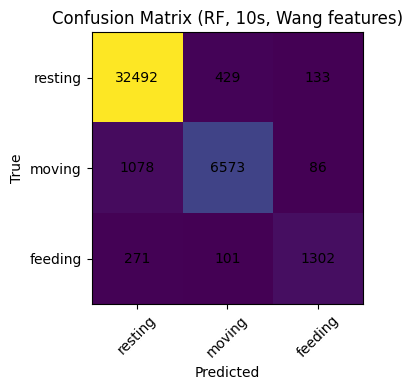

Saved model + scaler + feature list to: /content/drive/MyDrive/123F Models/experiments/20250819_0821_rf10s_wang


In [ ]:
# --- 6) Core runner (10s only) ---
def run_rf_wang_10s(overlap: float = 0.5):
    print("\n" + "="*75)
    print(f"Running RF (Wang features) with window_sec={WINDOW_SEC:.1f}, overlap={overlap*100:.0f}%")
    print("="*75)

    WINDOW = int(WINDOW_SEC * FS)
    HOP = max(1, int(WINDOW * (1 - overlap)))
    print({"WINDOW": WINDOW, "HOP": HOP})

    rows = []
    for path in FILES:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", os.path.basename(path), "->", e)
            continue

        df[LAB_COL] = normalize_label_series(df[LAB_COL])
        df = df[df[LAB_COL].isin(TARGET_LABELS)].copy()
        if df.empty:
            continue

        # Extract numeric arrays
        ax = pd.to_numeric(df[AX_COL], errors="coerce").to_numpy()
        ay = pd.to_numeric(df[AY_COL], errors="coerce").to_numpy()
        az = pd.to_numeric(df[AZ_COL], errors="coerce").to_numpy()
        sec = pd.to_numeric(df[SEC_COL], errors="coerce").to_numpy()
        lab = df[LAB_COL].to_numpy()

        n = len(df)
        if n < WINDOW:
            continue

        # Precompute dynamic components
        dx, dy, dz, dm = compute_dynamic(ax, ay, az, FS, win_sec=2.0)  # Wang-style static removal

        # Also compute raw magnitude for your existing stats
        mag = np.sqrt(ax*ax + ay*ay + az*az)

        for start in range(0, n - WINDOW + 1, HOP):
            end = start + WINDOW
            sl = slice(start, end)

            # majority label in window
            win_labels = lab[sl]
            if len(win_labels) == 0:
                continue
            vc = pd.Series(win_labels).value_counts()
            win_label = vc.index[0]
            if win_label not in TARGET_LABELS:
                continue

            # Windowed arrays
            axw, ayw, azw = ax[sl], ay[sl], az[sl]
            dxw, dyw, dzw, dmw = dx[sl], dy[sl], dz[sl], dm[sl]
            magw = mag[sl]

            feats = {}

            # --- (A) Your existing descriptive stats on raw & magnitude ---
            for nm, arr in [("ax", axw), ("ay", ayw), ("az", azw), ("mag", magw)]:
                feats[f"{nm}_mean"] = float(np.nanmean(arr))
                feats[f"{nm}_std"]  = float(np.nanstd(arr))
                feats[f"{nm}_min"]  = float(np.nanmin(arr))
                feats[f"{nm}_max"]  = float(np.nanmax(arr))
                q75, q25 = np.nanpercentile(arr, 75), np.nanpercentile(arr, 25)
                feats[f"{nm}_iqr"]  = float(q75 - q25)
                feats[f"{nm}_madiff"] = float(np.nanmean(np.abs(np.diff(arr)))) if len(arr) > 1 else 0.0

            # --- (B) Wang-style dynamic features ---
            # ODBA per axis (mean |dynamic|), and ODBA_sum
            feats["ODBA_X"] = float(np.nanmean(np.abs(dxw)))
            feats["ODBA_Y"] = float(np.nanmean(np.abs(dyw)))
            feats["ODBA_Z"] = float(np.nanmean(np.abs(dzw)))
            feats["ODBA_Sum"] = feats["ODBA_X"] + feats["ODBA_Y"] + feats["ODBA_Z"]

            # Standard deviation of dynamic accel per axis + dynamic magnitude (SDX/SDY/SDZ/SDM)
            feats["SDX_dyn"] = float(np.nanstd(dxw))
            feats["SDY_dyn"] = float(np.nanstd(dyw))
            feats["SDZ_dyn"] = float(np.nanstd(dzw))
            feats["SDM_dyn"] = float(np.nanstd(dmw))

            # Dominant frequency & amplitude for each dynamic axis and dynamic magnitude
            for nm, arr in [("X", dxw), ("Y", dyw), ("Z", dzw), ("M", dmw)]:
                f_dom, amp_dom = dominant_freq_amp(arr, FS)
                feats[f"DF{nm}"] = f_dom    # Hz
                feats[f"Amp{nm}"] = amp_dom # magnitude of FFT peak

            # --- (C) Refined bandpowers on dynamic magnitude (chewing/walking bands) ---
            bp = bandpowers(dmw, FS, BANDS)
            for i, (f1, f2) in enumerate(BANDS):
                feats[f"dm_bp_{f1:.1f}_{f2:.1f}"] = bp[i]

            # Timing/meta
            feats["t_start"] = float(sec[start]) if not math.isnan(sec[start]) else float(start/FS)
            feats["t_end"]   = float(sec[end-1]) if not math.isnan(sec[end-1]) else float((end-1)/FS)
            feats["hour_file"] = os.path.basename(path)
            feats["label"] = win_label

            rows.append(feats)

    if not rows:
        raise RuntimeError("No windows extracted. Check DATA_ROOT, filenames, or filters.")
    data = pd.DataFrame(rows)
    print("Feature table:", data.shape)
    print("Label counts:\n", data["label"].value_counts())


    # --- Train/test split ---
    feat_cols = [c for c in data.columns if c not in ("label", "hour_file", "t_start", "t_end")]
    train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, shuffle=True)
    print("Train windows:", len(train_df), "Test windows:", len(test_df))

    X_train = train_df[feat_cols].to_numpy()
    y_train = train_df["label"].to_numpy()
    X_test  = test_df[feat_cols].to_numpy()
    y_test  = test_df["label"].to_numpy()

    # --- Scale + RF ---
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight=CLASS_WEIGHT,  # "balanced" by default; switch to dict later if needed
        n_jobs=-1,
        random_state=42,
        bootstrap=True,
        max_features="sqrt"
    )
    rf.fit(X_train_sc, y_train)

    # --- Evaluate ---
    y_pred = rf.predict(X_test_sc)
    print("\nClassification report (3 classes):")
    print(classification_report(
        y_test, y_pred,
        labels=LABELS_ORDER,
        target_names=LABELS_ORDER,
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred, labels=LABELS_ORDER)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix (RF, 10s, Wang features)")
    plt.xticks(range(len(LABELS_ORDER)), LABELS_ORDER, rotation=45)
    plt.yticks(range(len(LABELS_ORDER)), LABELS_ORDER)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

    # --- Verification CSV (side-by-side) ---
    if WRITE_VERIFICATION_CSV:
        proba = rf.predict_proba(X_test_sc)
        # Map proba columns to LABELS_ORDER (sklearn orders classes alphabetically)
        class_index = {c:i for i,c in enumerate(rf.classes_)}
        def p_of(lbl): return proba[:, class_index[lbl]] if lbl in class_index else np.zeros(len(y_pred))
        verif = test_df[["hour_file","t_start","t_end","label"]].copy()
        verif = verif.rename(columns={"label":"true_label"})
        verif["pred_label"] = y_pred
        # add confidences for each class and the predicted class confidence
        for lbl in LABELS_ORDER:
            verif[f"p_{lbl}"] = p_of(lbl)
        verif["p_pred"] = verif.apply(lambda r: r[f"p_{r['pred_label']}"], axis=1)
        out_csv = os.path.join(OUTPUT_DIR, "verification_10s_wang.csv")
        verif.to_csv(out_csv, index=False)
        print("Wrote verification CSV ->", out_csv)

    # --- Save artifacts ---
    joblib.dump(rf, os.path.join(OUTPUT_DIR, "rf_10s_wang.joblib"))
    joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler_10s_wang.joblib"))
    with open(os.path.join(OUTPUT_DIR, "feature_columns_10s_wang.json"), "w") as f:
        json.dump(feat_cols, f, indent=2)
    print("Saved model + scaler + feature list to:", OUTPUT_DIR)

# --- 7) Run (single 10s experiment) ---
if len(FILES) == 0:
    print("⚠️ No files will be processed. Fix DATA_ROOT, then re-run this cell.")
else:
    run_rf_wang_10s(overlap=OVERLAP)






In [ ]:

    # --- Train/test split ---
    feat_cols = [c for c in data.columns if c not in ("label", "hour_file", "t_start", "t_end")]
    train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, shuffle=True)
    print("Train windows:", len(train_df), "Test windows:", len(test_df))

    X_train = train_df[feat_cols].to_numpy()
    y_train = train_df["label"].to_numpy()
    X_test  = test_df[feat_cols].to_numpy()
    y_test  = test_df["label"].to_numpy()

    # --- Scale + RF ---
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight=CLASS_WEIGHT,  # "balanced" by default; switch to dict later if needed
        n_jobs=-1,
        random_state=42,
        bootstrap=True,
        max_features="sqrt"
    )
    rf.fit(X_train_sc, y_train)

    # --- Evaluate ---
    y_pred = rf.predict(X_test_sc)
    print("\nClassification report (3 classes):")
    print(classification_report(
        y_test, y_pred,
        labels=LABELS_ORDER,
        target_names=LABELS_ORDER,
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred, labels=LABELS_ORDER)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix (RF, 10s, Wang features)")
    plt.xticks(range(len(LABELS_ORDER)), LABELS_ORDER, rotation=45)
    plt.yticks(range(len(LABELS_ORDER)), LABELS_ORDER)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

    # --- Verification CSV (side-by-side) ---
    if WRITE_VERIFICATION_CSV:
        proba = rf.predict_proba(X_test_sc)
        # Map proba columns to LABELS_ORDER (sklearn orders classes alphabetically)
        class_index = {c:i for i,c in enumerate(rf.classes_)}
        def p_of(lbl): return proba[:, class_index[lbl]] if lbl in class_index else np.zeros(len(y_pred))
        verif = test_df[["hour_file","t_start","t_end","label"]].copy()
        verif = verif.rename(columns={"label":"true_label"})
        verif["pred_label"] = y_pred
        # add confidences for each class and the predicted class confidence
        for lbl in LABELS_ORDER:
            verif[f"p_{lbl}"] = p_of(lbl)
        verif["p_pred"] = verif.apply(lambda r: r[f"p_{r['pred_label']}"], axis=1)
        out_csv = os.path.join(OUTPUT_DIR, "verification_10s_wang.csv")
        verif.to_csv(out_csv, index=False)
        print("Wrote verification CSV ->", out_csv)

    # --- Save artifacts ---
    joblib.dump(rf, os.path.join(OUTPUT_DIR, "rf_10s_wang.joblib"))
    joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler_10s_wang.joblib"))
    with open(os.path.join(OUTPUT_DIR, "feature_columns_10s_wang.json"), "w") as f:
        json.dump(feat_cols, f, indent=2)
    print("Saved model + scaler + feature list to:", OUTPUT_DIR)

# --- 7) Run (single 10s experiment) ---
if len(FILES) == 0:
    print("⚠️ No files will be processed. Fix DATA_ROOT, then re-run this cell.")
else:
    run_rf_wang_10s(overlap=OVERLAP)


In [ ]:
!pip install cuml-cuda11

ERROR: Could not find a version that satisfies the requirement cuml-cuda11 (from versions: none)
ERROR: No matching distribution found for cuml-cuda11


In [ ]:
# Import the cuml RandomForestClassifier
from cuml.ensemble import RandomForestClassifier as cuRandomForestClassifier

**After adding Wang's features, we note some small improvements on feeding compared to original 10 s RF. Next up is the same Wang features, but this time with autocorrelation and a mismatch sampler to see where the errors might be falling**

In [ ]:
# =========================================
# 123F – RF (10s) with Wang features + Autocorr + Mismatch Sampler
# =========================================

# --- 0) Imports ---
import os, re, glob, json, math, warnings, random
from datetime import datetime
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

warnings.filterwarnings("ignore", category=UserWarning)

# --- 1) Mount Drive (safe if already mounted) ---
drive.mount('/content/drive', force_remount=False)

# --- 2) Config ---
DATA_ROOT = "/content/drive/MyDrive/123F Labeled Accel Data (Final)"
FS = 16  # Hz
WINDOW_SEC = 10.0
OVERLAP = 0.5
TARGET_LABELS = {"resting", "moving", "feeding"}
LABELS_ORDER = ["resting", "moving", "feeding"]

# Output folder (new; won’t overwrite prior runs)
STAMP = datetime.now().strftime("%Y%m%d_%H%M")
OUTPUT_DIR = f"/content/drive/MyDrive/123F Models/experiments/{STAMP}_rf10s_wang_autocorr"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Writing artifacts to:", OUTPUT_DIR)

# Toggles
WRITE_VERIFICATION_CSV = False           # keep OFF (huge)
WRITE_MISMATCH_SAMPLE = True            # ON: small CSV with errors only
MISMATCH_SAMPLE_MAX = 2000              # cap rows in mismatch sample CSV

# Class-weight: start "balanced"; later, try e.g. {"resting":1.0,"moving":1.2,"feeding":2.5}
CLASS_WEIGHT = "balanced"

# --- 3) File discovery (exclude hour 15 everywhere) ---
def find_all_hour_files(data_root: str):
    patt1 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.csv"), recursive=True)
    patt2 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.CSV"), recursive=True)
    return sorted(set(patt1 + patt2))

def is_hour_15(path: str) -> bool:
    base = os.path.basename(path)
    m = re.search(r"_(\d{2})_synced_labeled\.csv$", base, flags=re.IGNORECASE)
    return (m is not None) and (m.group(1) == "15")

ALL_FILES = find_all_hour_files(DATA_ROOT)
FILES = [f for f in ALL_FILES if not is_hour_15(f)]
print(f"Found {len(ALL_FILES)} files; using {len(FILES)} (excluded hour-15 where present).")
if len(ALL_FILES) == 0:
    print("⚠️ No files found. Double-check DATA_ROOT path and that this isn't a Drive shortcut.")

# --- 4) Column names ---
AX_COL, AY_COL, AZ_COL = "Acc X [g]", "Acc Y [g]", "Acc Z [g]"
SEC_COL, LAB_COL = "Seconds", "Label"

# --- 5) Helpers ---
def normalize_label_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()

def moving_average(x: np.ndarray, k: int) -> np.ndarray:
    if k <= 1 or len(x) == 0:
        return x.copy()
    kern = np.ones(k, dtype=float) / float(k)
    return np.convolve(x, kern, mode="same")

def compute_dynamic(ax: np.ndarray, ay: np.ndarray, az: np.ndarray, fs: float, win_sec: float = 2.0):
    """Static ~ 2s smoothing; dynamic = raw - static (Wang)."""
    k = max(1, int(round(win_sec * fs)))
    ax_stat = moving_average(ax, k)
    ay_stat = moving_average(ay, k)
    az_stat = moving_average(az, k)
    dx, dy, dz = ax - ax_stat, ay - ay_stat, az - az_stat
    dm = np.sqrt(dx*dx + dy*dy + dz*dz)
    return dx, dy, dz, dm

def dominant_freq_amp(sig: np.ndarray, fs: float) -> Tuple[float, float]:
    n = len(sig)
    if n < 4:
        return 0.0, 0.0
    x = sig - np.nanmean(sig)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    if len(freqs) <= 1:
        return 0.0, 0.0
    X = X.copy()
    X[0] = 0.0 + 0.0j  # ignore DC
    idx = int(np.nanargmax(np.abs(X)))
    return float(freqs[idx]), float(np.abs(X[idx]))

def bandpowers(sig: np.ndarray, fs: float, bands: List[Tuple[float, float]]) -> List[float]:
    if len(sig) < 4:
        return [0.0] * len(bands)
    x = sig - np.nanmean(sig)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    X = np.fft.rfft(x)
    psd = (np.abs(X) ** 2) / max(n, 1)
    return [float(np.nanmean(psd[(freqs>=f1) & (freqs<f2)])) if np.any((freqs>=f1) & (freqs<f2)) else 0.0
            for (f1, f2) in bands]

# New: autocorrelation features on dynamic magnitude
def ac_features(sig: np.ndarray, fs: float, max_lag_s: float = 1.5):
    """
    Normalized autocorrelation features (excluding lag 0), focused on short lags
    where chewing/stride rhythms live. Returns dict with:
      - ac_max: max normalized ACF (lag>=1)
      - ac_lag_max_s: lag (s) of ac_max
      - ac_mean_3_8: mean ACF over lags 3..8 (~2–5 Hz at 16 Hz)
      - ac_mean_9_16: mean ACF over lags 9..16 (~1–1.8 Hz)
    """
    n = len(sig)
    out = {"ac_max": 0.0, "ac_lag_max_s": 0.0, "ac_mean_3_8": 0.0, "ac_mean_9_16": 0.0}
    if n < 4:
        return out
    x = sig - np.nanmean(sig)
    # full autocorr then take non-negative lags
    corr = np.correlate(x, x, mode="full")
    mid = len(corr) // 2
    ac = corr[mid:]  # lags 0..n-1
    if ac[0] <= 0:
        return out
    ac = ac / ac[0]  # normalize
    L = min(int(round(max_lag_s * fs)), len(ac)-1)
    if L < 1:
        return out
    ac_pos = ac[1:L+1]  # exclude lag 0
    # max & lag
    k = int(np.argmax(ac_pos))
    out["ac_max"] = float(ac_pos[k])
    out["ac_lag_max_s"] = float((k+1) / fs)
    # banded means
    def safe_mean(a, lo, hi):
        lo = max(lo, 1); hi = min(hi, len(ac)-1)
        if hi < lo: return 0.0
        seg = ac[lo:hi+1]
        return float(np.nanmean(seg)) if seg.size else 0.0
    out["ac_mean_3_8"]  = safe_mean(ac, 3, 8)    # ~2–5 Hz
    out["ac_mean_9_16"] = safe_mean(ac, 9, 16)   # ~1–1.8 Hz
    return out

# Refined bands (Nyquist = 8 Hz at 16 Hz FS)
BANDS = [(0.1, 0.5), (0.5, 2.0), (2.0, 4.0), (4.0, 6.0), (6.0, 8.0)]

# --- 6) Core runner (10s only) ---
def run_rf_wang_10s_autocorr(overlap: float = 0.5):
    print("\n" + "="*75)
    print(f"Running RF (Wang + autocorr) with window_sec={WINDOW_SEC:.1f}, overlap={overlap*100:.0f}%")
    print("="*75)

    WINDOW = int(WINDOW_SEC * FS)
    HOP = max(1, int(WINDOW * (1 - overlap)))
    print({"WINDOW": WINDOW, "HOP": HOP})

    rows = []
    for path in FILES:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", os.path.basename(path), "->", e)
            continue

        df[LAB_COL] = normalize_label_series(df[LAB_COL])
        df = df[df[LAB_COL].isin(TARGET_LABELS)].copy()
        if df.empty:
            continue

        ax = pd.to_numeric(df[AX_COL], errors="coerce").to_numpy()
        ay = pd.to_numeric(df[AY_COL], errors="coerce").to_numpy()
        az = pd.to_numeric(df[AZ_COL], errors="coerce").to_numpy()
        sec = pd.to_numeric(df[SEC_COL], errors="coerce").to_numpy()
        lab = df[LAB_COL].to_numpy()

        n = len(df)
        if n < WINDOW:
            continue

        # dynamic signals (Wang)
        dx, dy, dz, dm = compute_dynamic(ax, ay, az, FS, win_sec=2.0)
        # raw magnitude for your original stats
        mag = np.sqrt(ax*ax + ay*ay + az*az)

        for start in range(0, n - WINDOW + 1, HOP):
            end = start + WINDOW
            sl = slice(start, end)

            # majority label
            win_labels = lab[sl]
            if len(win_labels) == 0:
                continue
            win_label = pd.Series(win_labels).value_counts().index[0]
            if win_label not in TARGET_LABELS:
                continue

            axw, ayw, azw = ax[sl], ay[sl], az[sl]
            dxw, dyw, dzw, dmw = dx[sl], dy[sl], dz[sl], dm[sl]
            magw = mag[sl]

            feats = {}

            # (A) Existing descriptive stats on raw & magnitude
            for nm, arr in [("ax", axw), ("ay", ayw), ("az", azw), ("mag", magw)]:
                feats[f"{nm}_mean"] = float(np.nanmean(arr))
                feats[f"{nm}_std"]  = float(np.nanstd(arr))
                feats[f"{nm}_min"]  = float(np.nanmin(arr))
                feats[f"{nm}_max"]  = float(np.nanmax(arr))
                q75, q25 = np.nanpercentile(arr, 75), np.nanpercentile(arr, 25)
                feats[f"{nm}_iqr"]  = float(q75 - q25)
                feats[f"{nm}_madiff"] = float(np.nanmean(np.abs(np.diff(arr)))) if len(arr) > 1 else 0.0

            # (B) Wang-style dynamic features
            feats["ODBA_X"] = float(np.nanmean(np.abs(dxw)))
            feats["ODBA_Y"] = float(np.nanmean(np.abs(dyw)))
            feats["ODBA_Z"] = float(np.nanmean(np.abs(dzw)))
            feats["ODBA_Sum"] = feats["ODBA_X"] + feats["ODBA_Y"] + feats["ODBA_Z"]

            feats["SDX_dyn"] = float(np.nanstd(dxw))
            feats["SDY_dyn"] = float(np.nanstd(dyw))
            feats["SDZ_dyn"] = float(np.nanstd(dzw))
            feats["SDM_dyn"] = float(np.nanstd(dmw))

            for nm, arr in [("X", dxw), ("Y", dyw), ("Z", dzw), ("M", dmw)]:
                f_dom, amp_dom = dominant_freq_amp(arr, FS)
                feats[f"DF{nm}"] = f_dom
                feats[f"Amp{nm}"] = amp_dom

            # (C) Bandpowers on dynamic magnitude
            bp = bandpowers(dmw, FS, BANDS)
            for i, (f1, f2) in enumerate(BANDS):
                feats[f"dm_bp_{f1:.1f}_{f2:.1f}"] = bp[i]

            # (D) NEW: autocorrelation features on dynamic magnitude
            acf = ac_features(dmw, FS, max_lag_s=1.5)
            for k, v in acf.items():
                feats[k] = v

            # timing/meta
            feats["t_start"] = float(sec[start]) if not math.isnan(sec[start]) else float(start/FS)
            feats["t_end"]   = float(sec[end-1]) if not math.isnan(sec[end-1]) else float((end-1)/FS)
            feats["hour_file"] = os.path.basename(path)
            feats["label"] = win_label

            rows.append(feats)

    if not rows:
        raise RuntimeError("No windows extracted. Check DATA_ROOT, filenames, or filters.")
    data = pd.DataFrame(rows)
    print("Feature table:", data.shape)
    print("Label counts:\n", data["label"].value_counts())

    # --- Train/test split ---
    feat_cols = [c for c in data.columns if c not in ("label", "hour_file", "t_start", "t_end")]
    train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, shuffle=True)
    print("Train windows:", len(train_df), "Test windows:", len(test_df))

    X_train = train_df[feat_cols].to_numpy()
    y_train = train_df["label"].to_numpy()
    X_test  = test_df[feat_cols].to_numpy()
    y_test  = test_df["label"].to_numpy()

    # --- Scale + RF ---
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight=CLASS_WEIGHT,
        n_jobs=-1,
        random_state=42,
        bootstrap=True,
        max_features="sqrt"
    )
    rf.fit(X_train_sc, y_train)

    # --- Evaluate ---
    y_pred = rf.predict(X_test_sc)
    print("\nClassification report (3 classes):")
    print(classification_report(
        y_test, y_pred,
        labels=LABELS_ORDER,
        target_names=LABELS_ORDER,
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred, labels=LABELS_ORDER)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix (RF, 10s, Wang + autocorr)")
    plt.xticks(range(len(LABELS_ORDER)), LABELS_ORDER, rotation=45)
    plt.yticks(range(len(LABELS_ORDER)), LABELS_ORDER)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.ylabel("True"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

    # --- Optional: full verification CSV (disabled by default) ---
    if WRITE_VERIFICATION_CSV or WRITE_MISMATCH_SAMPLE:
        proba = rf.predict_proba(X_test_sc)
        class_index = {c:i for i,c in enumerate(rf.classes_)}
        def p_of(lbl): return proba[:, class_index[lbl]] if lbl in class_index else np.zeros(len(y_pred))

        verif = test_df[["hour_file","t_start","t_end","label"]].copy().rename(columns={"label":"true_label"})
        verif["pred_label"] = y_pred
        for lbl in LABELS_ORDER:
            verif[f"p_{lbl}"] = p_of(lbl)
        verif["p_pred"] = verif.apply(lambda r: r[f"p_{r['pred_label']}"], axis=1)

        if WRITE_VERIFICATION_CSV:
            big_csv = os.path.join(OUTPUT_DIR, "verification_full_10s_autocorr.csv")
            verif.to_csv(big_csv, index=False)
            print("Wrote verification CSV ->", big_csv)

        if WRITE_MISMATCH_SAMPLE:
            mism = verif[verif["true_label"] != verif["pred_label"]].copy()
            # cap rows for practicality
            if len(mism) > MISMATCH_SAMPLE_MAX:
                mism = mism.sample(MISMATCH_SAMPLE_MAX, random_state=42)
            small_csv = os.path.join(OUTPUT_DIR, f"mismatches_sample_{len(mism)}rows.csv")
            mism.to_csv(small_csv, index=False)
            print("Wrote mismatch sample CSV ->", small_csv)

    # --- Save artifacts ---
    joblib.dump(rf, os.path.join(OUTPUT_DIR, "rf_10s_wang_autocorr.joblib"))
    joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler_10s_wang_autocorr.joblib"))
    with open(os.path.join(OUTPUT_DIR, "feature_columns_10s_wang_autocorr.json"), "w") as f:
        json.dump(feat_cols, f, indent=2)
    print("Saved model + scaler + feature list to:", OUTPUT_DIR)

# --- 7) Run ---
if len(FILES) == 0:
    print("⚠️ No files will be processed. Fix DATA_ROOT, then re-run this cell.")
else:
    run_rf_wang_10s_autocorr(overlap=OVERLAP)

**This latest autocorrelation step did not yield any improvements (all table outputs are the same). The next recommended step is to introduce temporal smoothing to override potential one-off flips in the model's predictions for labeling, i.e. erroneosly flipping from "resting -> moving -> resting" in a resting bout due to a slight jerk, for instance. The smoothing will apply a median filter over 3 windows (i.e. a 30 second smoothing)**

In [ ]:
# =========================================
# 123F – Smoothing check for 10s RF (Wang + autocorr)
# Produces BEFORE vs AFTER (3-window majority filter) metrics
# =========================================

import os, re, glob, json, math, warnings
from datetime import datetime
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

warnings.filterwarnings("ignore", category=UserWarning)
drive.mount('/content/drive', force_remount=False)

# -------- Config --------
DATA_ROOT   = "/content/drive/MyDrive/123F Labeled Accel Data (Final)"
FS          = 16          # Hz
WINDOW_SEC  = 10.0
OVERLAP     = 0.5
HOP_S       = WINDOW_SEC * (1.0 - OVERLAP)   # each window contributes this many seconds to time budgets
TARGET_LABELS = {"resting", "moving", "feeding"}
LABELS_ORDER  = ["resting", "moving", "feeding"]
CLASS_WEIGHT  = "balanced"   # keep as before; we’re evaluating smoothing, not re-weighting

# -------- File discovery --------
def find_all_hour_files(data_root: str):
    patt1 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.csv"), recursive=True)
    patt2 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.CSV"), recursive=True)
    return sorted(set(patt1 + patt2))

def is_hour_15(path: str) -> bool:
    base = os.path.basename(path)
    m = re.search(r"_(\d{2})_synced_labeled\.csv$", base, flags=re.IGNORECASE)
    return (m is not None) and (m.group(1) == "15")

ALL_FILES = find_all_hour_files(DATA_ROOT)
FILES = [f for f in ALL_FILES if not is_hour_15(f)]
print(f"Found {len(ALL_FILES)} files; using {len(FILES)} (excluded hour-15 where present).")

# -------- Helpers (same as before) --------
AX_COL, AY_COL, AZ_COL = "Acc X [g]", "Acc Y [g]", "Acc Z [g]"
SEC_COL, LAB_COL = "Seconds", "Label"

def normalize_label_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()

def moving_average(x: np.ndarray, k: int) -> np.ndarray:
    if k <= 1 or len(x) == 0:
        return x.copy()
    kern = np.ones(k, dtype=float) / float(k)
    return np.convolve(x, kern, mode="same")

def compute_dynamic(ax: np.ndarray, ay: np.ndarray, az: np.ndarray, fs: float, win_sec: float = 2.0):
    k = max(1, int(round(win_sec * fs)))
    ax_stat = moving_average(ax, k)
    ay_stat = moving_average(ay, k)
    az_stat = moving_average(az, k)
    dx, dy, dz = ax - ax_stat, ay - ay_stat, az - az_stat
    dm = np.sqrt(dx*dx + dy*dy + dz*dz)
    return dx, dy, dz, dm

def dominant_freq_amp(sig: np.ndarray, fs: float) -> Tuple[float, float]:
    n = len(sig)
    if n < 4:
        return 0.0, 0.0
    x = sig - np.nanmean(sig)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    if len(freqs) <= 1:
        return 0.0, 0.0
    X = X.copy(); X[0] = 0.0 + 0.0j  # ignore DC
    idx = int(np.nanargmax(np.abs(X)))
    return float(freqs[idx]), float(np.abs(X[idx]))

def bandpowers(sig: np.ndarray, fs: float, bands: List[Tuple[float, float]]) -> List[float]:
    if len(sig) < 4:
        return [0.0] * len(bands)
    x = sig - np.nanmean(sig)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    X = np.fft.rfft(x)
    psd = (np.abs(X) ** 2) / max(n, 1)
    return [float(np.nanmean(psd[(freqs>=f1) & (freqs<f2)])) if np.any((freqs>=f1) & (freqs<f2)) else 0.0
            for (f1, f2) in bands]

def ac_features(sig: np.ndarray, fs: float, max_lag_s: float = 1.5):
    n = len(sig)
    out = {"ac_max": 0.0, "ac_lag_max_s": 0.0, "ac_mean_3_8": 0.0, "ac_mean_9_16": 0.0}
    if n < 4:
        return out
    x = sig - np.nanmean(sig)
    corr = np.correlate(x, x, mode="full")
    mid = len(corr) // 2
    ac = corr[mid:]
    if ac[0] <= 0:
        return out
    ac = ac / ac[0]
    L = min(int(round(max_lag_s * fs)), len(ac)-1)
    if L < 1:
        return out
    ac_pos = ac[1:L+1]
    k = int(np.argmax(ac_pos))
    out["ac_max"] = float(ac_pos[k])
    out["ac_lag_max_s"] = float((k+1) / fs)
    def safe_mean(a, lo, hi):
        lo = max(lo, 1); hi = min(hi, len(ac)-1)
        if hi < lo: return 0.0
        seg = ac[lo:hi+1]
        return float(np.nanmean(seg)) if seg.size else 0.0
    out["ac_mean_3_8"]  = safe_mean(ac, 3, 8)
    out["ac_mean_9_16"] = safe_mean(ac, 9, 16)
    return out

BANDS = [(0.1, 0.5), (0.5, 2.0), (2.0, 4.0), (4.0, 6.0), (6.0, 8.0)]

# -------- Build features (10 s, Wang + autocorr) --------
def build_feature_table(files: List[str], fs: float, window_sec: float, overlap: float):
    WINDOW = int(window_sec * fs)
    HOP = max(1, int(WINDOW * (1 - overlap)))
    rows = []
    for path in files:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", os.path.basename(path), "->", e); continue
        df[LAB_COL] = normalize_label_series(df[LAB_COL])
        df = df[df[LAB_COL].isin(TARGET_LABELS)].copy()
        if df.empty: continue

        ax = pd.to_numeric(df[AX_COL], errors="coerce").to_numpy()
        ay = pd.to_numeric(df[AY_COL], errors="coerce").to_numpy()
        az = pd.to_numeric(df[AZ_COL], errors="coerce").to_numpy()
        sec = pd.to_numeric(df[SEC_COL], errors="coerce").to_numpy()
        lab = df[LAB_COL].to_numpy()

        n = len(df)
        if n < WINDOW: continue

        dx, dy, dz, dm = compute_dynamic(ax, ay, az, fs, win_sec=2.0)
        mag = np.sqrt(ax*ax + ay*ay + az*az)

        for start in range(0, n - WINDOW + 1, HOP):
            end = start + WINDOW
            sl = slice(start, end)
            win_labels = lab[sl]
            if len(win_labels) == 0: continue
            win_label = pd.Series(win_labels).value_counts().index[0]
            if win_label not in TARGET_LABELS: continue

            axw, ayw, azw = ax[sl], ay[sl], az[sl]
            dxw, dyw, dzw, dmw = dx[sl], dy[sl], dz[sl], dm[sl]
            magw = mag[sl]

            feats = {}
            # Existing stats
            for nm, arr in [("ax", axw), ("ay", ayw), ("az", azw), ("mag", magw)]:
                feats[f"{nm}_mean"] = float(np.nanmean(arr))
                feats[f"{nm}_std"]  = float(np.nanstd(arr))
                feats[f"{nm}_min"]  = float(np.nanmin(arr))
                feats[f"{nm}_max"]  = float(np.nanmax(arr))
                q75, q25 = np.nanpercentile(arr, 75), np.nanpercentile(arr, 25)
                feats[f"{nm}_iqr"]  = float(q75 - q25)
                feats[f"{nm}_madiff"] = float(np.nanmean(np.abs(np.diff(arr)))) if len(arr) > 1 else 0.0

            # Wang-style dynamics
            feats["ODBA_X"] = float(np.nanmean(np.abs(dxw)))
            feats["ODBA_Y"] = float(np.nanmean(np.abs(dyw)))
            feats["ODBA_Z"] = float(np.nanmean(np.abs(dzw)))
            feats["ODBA_Sum"] = feats["ODBA_X"] + feats["ODBA_Y"] + feats["ODBA_Z"]
            feats["SDX_dyn"] = float(np.nanstd(dxw))
            feats["SDY_dyn"] = float(np.nanstd(dyw))
            feats["SDZ_dyn"] = float(np.nanstd(dzw))
            feats["SDM_dyn"] = float(np.nanstd(dmw))
            for nm, arr in [("X", dxw), ("Y", dyw), ("Z", dzw), ("M", dmw)]:
                f_dom, amp_dom = dominant_freq_amp(arr, FS)
                feats[f"DF{nm}"] = f_dom
                feats[f"Amp{nm}"] = amp_dom

            # Bandpowers on dynamic magnitude
            bp = bandpowers(dmw, FS, BANDS)
            for i, (f1, f2) in enumerate(BANDS):
                feats[f"dm_bp_{f1:.1f}_{f2:.1f}"] = bp[i]

            # Autocorr features (already seen did not change metrics much—but keep for completeness)
            acf = ac_features(dmw, FS, max_lag_s=1.5)
            for k, v in acf.items():
                feats[k] = v

            feats["t_start"]   = float(sec[start]) if not math.isnan(sec[start]) else float(start/FS)
            feats["t_end"]     = float(sec[end-1]) if not math.isnan(sec[end-1]) else float((end-1)/FS)
            feats["hour_file"] = os.path.basename(path)
            feats["label"]     = win_label
            rows.append(feats)

    data = pd.DataFrame(rows)
    return data

print("Building features…")
data = build_feature_table(FILES, FS, WINDOW_SEC, OVERLAP)
print("Feature table:", data.shape)
print("Label counts:\n", data["label"].value_counts())

# -------- Train/Test split & fit RF --------
feat_cols = [c for c in data.columns if c not in ("label","hour_file","t_start","t_end")]
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, shuffle=True)
X_train = train_df[feat_cols].to_numpy()
y_train = train_df["label"].to_numpy()
X_test  = test_df[feat_cols].to_numpy()
y_test  = test_df["label"].to_numpy()

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=500, class_weight=CLASS_WEIGHT,
    n_jobs=-1, random_state=42, bootstrap=True, max_features="sqrt"
)
rf.fit(X_train_sc, y_train)

# -------- BEFORE: raw predictions --------
y_pred_raw = rf.predict(X_test_sc)
proba = rf.predict_proba(X_test_sc)
classes = list(rf.classes_)
class_index = {c:i for i,c in enumerate(classes)}
def p_of(lbl): return proba[:, class_index[lbl]] if lbl in class_index else np.zeros(len(y_pred_raw))

print("\nBEFORE (raw) classification report:")
print(classification_report(y_test, y_pred_raw, labels=LABELS_ORDER, target_names=LABELS_ORDER, zero_division=0))

# -------- Smoothing: 3-window majority filter per hour_file --------
def majority3(arr):
    """Return majority label over arr of length 3; tie -> keep center element."""
    if len(arr) == 1: return arr[0]
    if len(arr) == 2:
        return arr[0] if arr[0]==arr[1] else arr[1]  # leaning to later window
    a,b,c = arr[0], arr[1], arr[2]
    if a==b or a==c: return a
    if b==c: return b
    return b  # all different, keep center

# assemble a DataFrame for test predictions with ordering
pred_df = test_df[["hour_file","t_start","label"]].copy().rename(columns={"label":"true_label"})
pred_df["pred_raw"] = y_pred_raw

# apply rolling majority within each hour_file ordered by time
pred_df = pred_df.sort_values(["hour_file","t_start"]).reset_index(drop=True)

def smooth_group(g):
    vals = g["pred_raw"].to_list()
    smoothed = []
    n = len(vals)
    for i in range(n):
        # window centered at i: [i-1, i, i+1] with edges handled
        win = [vals[j] for j in [i-1, i, i+1] if 0 <= j < n]
        smoothed.append(majority3(win))
    g["pred_smooth"] = smoothed
    return g

pred_df = pred_df.groupby("hour_file", group_keys=False).apply(smooth_group)

# align back to original order of y_test for fair reporting
# create a key to merge on (hour_file + t_start)
test_key = test_df[["hour_file","t_start"]].copy()
pred_df_keyed = pred_df.set_index(["hour_file","t_start"])
pred_smooth_aligned = []
for _, row in test_key.iterrows():
    pred_smooth_aligned.append(pred_df_keyed.loc[(row["hour_file"], row["t_start"]), "pred_smooth"])
y_pred_smooth = np.array(pred_smooth_aligned)

print("\nAFTER (smoothed) classification report:")
print(classification_report(y_test, y_pred_smooth, labels=LABELS_ORDER, target_names=LABELS_ORDER, zero_division=0))

# -------- Run-length stats (blip count & median run length) --------
def run_lengths(labels):
    """Return run lengths of contiguous equal labels in a list."""
    if len(labels)==0: return []
    runs = []
    cur = labels[0]; length = 1
    for x in labels[1:]:
        if x == cur:
            length += 1
        else:
            runs.append((cur, length))
            cur, length = x, 1
    runs.append((cur, length))
    return runs

def run_stats(df, col):
    out = []
    for hour, g in df.sort_values(["hour_file","t_start"]).groupby("hour_file"):
        labs = g[col].tolist()
        runs = run_lengths(labs)
        for lab in LABELS_ORDER:
            lens = [L for lab2,L in runs if lab2==lab]
            if len(lens)==0:
                out.append({"hour_file":hour, "label":lab, "n_runs":0, "n_runs_len1":0, "median_run":0})
            else:
                out.append({"hour_file":hour, "label":lab,
                            "n_runs":len(lens),
                            "n_runs_len1":sum(1 for L in lens if L==1),
                            "median_run":int(np.median(lens))})
    out = pd.DataFrame(out)
    # aggregate across hours
    agg = (out.groupby("label")
              .agg(n_runs=("n_runs","sum"),
                   n_runs_len1=("n_runs_len1","sum"),
                   frac_len1=("n_runs_len1", lambda s: float(s.sum())/max(float(out["n_runs"].sum()),1)),
                   median_run=("median_run","median"))
              .reset_index())
    return agg

pred_df["pred_raw"] = pred_df["pred_raw"].astype(str)
pred_df["pred_smooth"] = pred_df["pred_smooth"].astype(str)

rl_before = run_stats(pred_df, "pred_raw")
rl_after  = run_stats(pred_df, "pred_smooth")

print("\nRun-length summary (BEFORE):")
print(rl_before.to_string(index=False))
print("\nRun-length summary (AFTER smoothing):")
print(rl_after.to_string(index=False))

# -------- Time budget bias (aggregate over test subset) --------
# seconds contributed per window = HOP_S
sec_per_window = HOP_S

def budget_seconds(labels):
    # labels: array-like of class strings aligned with test_df
    s = pd.Series(labels, name="lbl")
    counts = s.value_counts()
    secs = {lab: counts.get(lab, 0) * sec_per_window for lab in LABELS_ORDER}
    return secs

true_secs   = budget_seconds(y_test)
raw_secs    = budget_seconds(y_pred_raw)
smooth_secs = budget_seconds(y_pred_smooth)

def print_budget(title, secs):
    mins = {k: v/60.0 for k,v in secs.items()}
    print(title, {k: f"{mins[k]:.1f} min" for k in LABELS_ORDER})

print("\nTime budgets over TEST SUBSET (weighted by hop = %.1fs per window):" % HOP_S)
print_budget("True   :", true_secs)
print_budget("Raw    :", raw_secs)
print_budget("Smoothed:", smooth_secs)

def budget_diff(secs_pred, secs_true):
    return {k: (secs_pred[k] - secs_true[k])/60.0 for k in LABELS_ORDER}

print("\nBudget bias (minutes, Pred − True):")
print("Raw vs True    :", budget_diff(raw_secs, true_secs))
print("Smooth vs True :", budget_diff(smooth_secs, true_secs))

**The 3-window (30 second) smoothing resulted in less one-off flips and smoother behavioral bouts, which more accurately matches the labeling style we did in Raven, where we looked at dominant state behaviors rather than micro-labels. It also helps us catch a bit more feeding (precision, recall, and f1 are all higher).**

**Next we can try a 5-window smoothing to compare, this might yield even better results:**

In [ ]:
# =========================================
# 123F – Smoothing check for 10s RF (Wang + autocorr)
# BEFORE vs AFTER (5-window majority filter)
# =========================================

import os, re, glob, json, math, warnings
from datetime import datetime
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from collections import Counter

warnings.filterwarnings("ignore", category=UserWarning)

if os.path.isdir("/content/drive/MyDrive"):
    print("Drive already mounted; skipping.")
else:
    drive.mount("/content/drive", force_remount=False)


# -------- Config --------
DATA_ROOT   = "/content/drive/MyDrive/123F Labeled Accel Data (Final)"
FS          = 16          # Hz
WINDOW_SEC  = 10.0
OVERLAP     = 0.5
HOP_S       = WINDOW_SEC * (1.0 - OVERLAP)   # each window contributes this many seconds to time budgets
TARGET_LABELS = {"resting", "moving", "feeding"}
LABELS_ORDER  = ["resting", "moving", "feeding"]
CLASS_WEIGHT  = "balanced"   # evaluating smoothing, not re-weighting

# -------- File discovery --------
def find_all_hour_files(data_root: str):
    patt1 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.csv"), recursive=True)
    patt2 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.CSV"), recursive=True)
    return sorted(set(patt1 + patt2))

def is_hour_15(path: str) -> bool:
    base = os.path.basename(path)
    m = re.search(r"_(\d{2})_synced_labeled\.csv$", base, flags=re.IGNORECASE)
    return (m is not None) and (m.group(1) == "15")

ALL_FILES = find_all_hour_files(DATA_ROOT)
FILES = [f for f in ALL_FILES if not is_hour_15(f)]
print(f"Found {len(ALL_FILES)} files; using {len(FILES)} (excluded hour-15 where present).")

# -------- Helpers (same as before) --------
AX_COL, AY_COL, AZ_COL = "Acc X [g]", "Acc Y [g]", "Acc Z [g]"
SEC_COL, LAB_COL = "Seconds", "Label"

def normalize_label_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()

def moving_average(x: np.ndarray, k: int) -> np.ndarray:
    if k <= 1 or len(x) == 0:
        return x.copy()
    kern = np.ones(k, dtype=float) / float(k)
    return np.convolve(x, kern, mode="same")

def compute_dynamic(ax: np.ndarray, ay: np.ndarray, az: np.ndarray, fs: float, win_sec: float = 2.0):
    k = max(1, int(round(win_sec * fs)))
    ax_stat = moving_average(ax, k)
    ay_stat = moving_average(ay, k)
    az_stat = moving_average(az, k)
    dx, dy, dz = ax - ax_stat, ay - ay_stat, az - az_stat
    dm = np.sqrt(dx*dx + dy*dy + dz*dz)
    return dx, dy, dz, dm

def dominant_freq_amp(sig: np.ndarray, fs: float) -> Tuple[float, float]:
    n = len(sig)
    if n < 4:
        return 0.0, 0.0
    x = sig - np.nanmean(sig)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    if len(freqs) <= 1:
        return 0.0, 0.0
    X = X.copy(); X[0] = 0.0 + 0.0j  # ignore DC
    idx = int(np.nanargmax(np.abs(X)))
    return float(freqs[idx]), float(np.abs(X[idx]))

def bandpowers(sig: np.ndarray, fs: float, bands: List[Tuple[float, float]]) -> List[float]:
    if len(sig) < 4:
        return [0.0] * len(bands)
    x = sig - np.nanmean(sig)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    X = np.fft.rfft(x)
    psd = (np.abs(X) ** 2) / max(n, 1)
    return [float(np.nanmean(psd[(freqs>=f1) & (freqs<f2)])) if np.any((freqs>=f1) & (freqs<f2)) else 0.0
            for (f1, f2) in bands]

def ac_features(sig: np.ndarray, fs: float, max_lag_s: float = 1.5):
    n = len(sig)
    out = {"ac_max": 0.0, "ac_lag_max_s": 0.0, "ac_mean_3_8": 0.0, "ac_mean_9_16": 0.0}
    if n < 4:
        return out
    x = sig - np.nanmean(sig)
    corr = np.correlate(x, x, mode="full")
    mid = len(corr) // 2
    ac = corr[mid:]
    if ac[0] <= 0:
        return out
    ac = ac / ac[0]
    L = min(int(round(max_lag_s * fs)), len(ac)-1)
    if L < 1:
        return out
    ac_pos = ac[1:L+1]
    k = int(np.argmax(ac_pos))
    out["ac_max"] = float(ac_pos[k])
    out["ac_lag_max_s"] = float((k+1) / fs)
    def safe_mean(a, lo, hi):
        lo = max(lo, 1); hi = min(hi, len(ac)-1)
        if hi < lo: return 0.0
        seg = ac[lo:hi+1]
        return float(np.nanmean(seg)) if seg.size else 0.0
    out["ac_mean_3_8"]  = safe_mean(ac, 3, 8)
    out["ac_mean_9_16"] = safe_mean(ac, 9, 16)
    return out

BANDS = [(0.1, 0.5), (0.5, 2.0), (2.0, 4.0), (4.0, 6.0), (6.0, 8.0)]

# -------- Build features (10 s, Wang + autocorr) --------
def build_feature_table(files: List[str], fs: float, window_sec: float, overlap: float):
    WINDOW = int(window_sec * fs)
    HOP = max(1, int(WINDOW * (1 - overlap)))
    rows = []
    for path in files:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", os.path.basename(path), "->", e); continue
        df[LAB_COL] = normalize_label_series(df[LAB_COL])
        df = df[df[LAB_COL].isin(TARGET_LABELS)].copy()
        if df.empty: continue

        ax = pd.to_numeric(df[AX_COL], errors="coerce").to_numpy()
        ay = pd.to_numeric(df[AY_COL], errors="coerce").to_numpy()
        az = pd.to_numeric(df[AZ_COL], errors="coerce").to_numpy()
        sec = pd.to_numeric(df[SEC_COL], errors="coerce").to_numpy()
        lab = df[LAB_COL].to_numpy()

        n = len(df)
        if n < WINDOW: continue

        dx, dy, dz, dm = compute_dynamic(ax, ay, az, fs, win_sec=2.0)
        mag = np.sqrt(ax*ax + ay*ay + az*az)

        for start in range(0, n - WINDOW + 1, HOP):
            end = start + WINDOW
            sl = slice(start, end)
            win_labels = lab[sl]
            if len(win_labels) == 0: continue
            win_label = pd.Series(win_labels).value_counts().index[0]
            if win_label not in TARGET_LABELS: continue

            axw, ayw, azw = ax[sl], ay[sl], az[sl]
            dxw, dyw, dzw, dmw = dx[sl], dy[sl], dz[sl], dm[sl]
            magw = mag[sl]

            feats = {}
            # Existing stats
            for nm, arr in [("ax", axw), ("ay", ayw), ("az", azw), ("mag", magw)]:
                feats[f"{nm}_mean"] = float(np.nanmean(arr))
                feats[f"{nm}_std"]  = float(np.nanstd(arr))
                feats[f"{nm}_min"]  = float(np.nanmin(arr))
                feats[f"{nm}_max"]  = float(np.nanmax(arr))
                q75, q25 = np.nanpercentile(arr, 75), np.nanpercentile(arr, 25)
                feats[f"{nm}_iqr"]  = float(q75 - q25)
                feats[f"{nm}_madiff"] = float(np.nanmean(np.abs(np.diff(arr)))) if len(arr) > 1 else 0.0

            # Wang-style dynamics
            feats["ODBA_X"] = float(np.nanmean(np.abs(dxw)))
            feats["ODBA_Y"] = float(np.nanmean(np.abs(dyw)))
            feats["ODBA_Z"] = float(np.nanmean(np.abs(dzw)))
            feats["ODBA_Sum"] = feats["ODBA_X"] + feats["ODBA_Y"] + feats["ODBA_Z"]
            feats["SDX_dyn"] = float(np.nanstd(dxw))
            feats["SDY_dyn"] = float(np.nanstd(dyw))
            feats["SDZ_dyn"] = float(np.nanstd(dzw))
            feats["SDM_dyn"] = float(np.nanstd(dmw))
            for nm, arr in [("X", dxw), ("Y", dyw), ("Z", dzw), ("M", dmw)]:
                f_dom, amp_dom = dominant_freq_amp(arr, FS)
                feats[f"DF{nm}"] = f_dom
                feats[f"Amp{nm}"] = amp_dom

            # Bandpowers on dynamic magnitude
            bp = bandpowers(dmw, FS, BANDS)
            for i, (f1, f2) in enumerate(BANDS):
                feats[f"dm_bp_{f1:.1f}_{f2:.1f}"] = bp[i]

            # Autocorr features
            acf = ac_features(dmw, FS, max_lag_s=1.5)
            for k, v in acf.items():
                feats[k] = v

            feats["t_start"]   = float(sec[start]) if not math.isnan(sec[start]) else float(start/FS)
            feats["t_end"]     = float(sec[end-1]) if not math.isnan(sec[end-1]) else float((end-1)/FS)
            feats["hour_file"] = os.path.basename(path)
            feats["label"]     = win_label
            rows.append(feats)

    data = pd.DataFrame(rows)
    return data

print("Building features…")
data = build_feature_table(FILES, FS, WINDOW_SEC, OVERLAP)
print("Feature table:", data.shape)
print("Label counts:\n", data["label"].value_counts())

# -------- Train/Test split & fit RF --------
feat_cols = [c for c in data.columns if c not in ("label","hour_file","t_start","t_end")]
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, shuffle=True)
X_train = train_df[feat_cols].to_numpy()
y_train = train_df["label"].to_numpy()
X_test  = test_df[feat_cols].to_numpy()
y_test  = test_df["label"].to_numpy()

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=500, class_weight=CLASS_WEIGHT,
    n_jobs=-1, random_state=42, bootstrap=True, max_features="sqrt"
)
rf.fit(X_train_sc, y_train)

# -------- BEFORE: raw predictions --------
y_pred_raw = rf.predict(X_test_sc)
proba = rf.predict_proba(X_test_sc)
classes = list(rf.classes_)
class_index = {c:i for i,c in enumerate(classes)}
def p_of(lbl): return proba[:, class_index[lbl]] if lbl in class_index else np.zeros(len(y_pred_raw))

print("\nBEFORE (raw) classification report:")
print(classification_report(y_test, y_pred_raw, labels=LABELS_ORDER, target_names=LABELS_ORDER, zero_division=0))

# -------- Smoothing: 5-window majority filter per hour_file --------
def majority_with_tiebreak(seq, center_label):
    """
    Majority vote over a list of labels (length up to 5).
    If there's a tie, return the center label (don't force a flip).
    """
    cnt = Counter(seq).most_common()
    if len(cnt) == 1:
        return cnt[0][0]
    if cnt[0][1] > cnt[1][1]:
        return cnt[0][0]
    return center_label  # tie -> keep center

def smooth_group_5(g):
    vals = g["pred_raw"].to_list()
    smoothed = []
    n = len(vals)
    for i in range(n):
        # 5-window centered at i: [i-2, i-1, i, i+1, i+2] (edges handled)
        idxs = [j for j in [i-2, i-1, i, i+1, i+2] if 0 <= j < n]
        win = [vals[j] for j in idxs]
        smoothed.append(majority_with_tiebreak(win, vals[i]))
    g["pred_smooth"] = smoothed
    return g

# assemble a DataFrame for test predictions with ordering
pred_df = test_df[["hour_file","t_start","label"]].copy().rename(columns={"label":"true_label"})
pred_df["pred_raw"] = y_pred_raw
pred_df = pred_df.sort_values(["hour_file","t_start"]).reset_index(drop=True)

pred_df = pred_df.groupby("hour_file", group_keys=False).apply(smooth_group_5)

# align back to original order of y_test for fair reporting
test_key = test_df[["hour_file","t_start"]].copy()
pred_df_keyed = pred_df.set_index(["hour_file","t_start"])
pred_smooth_aligned = []
for _, row in test_key.iterrows():
    pred_smooth_aligned.append(pred_df_keyed.loc[(row["hour_file"], row["t_start"]), "pred_smooth"])
y_pred_smooth = np.array(pred_smooth_aligned)

print("\nAFTER (5-window smoothed) classification report:")
print(classification_report(y_test, y_pred_smooth, labels=LABELS_ORDER, target_names=LABELS_ORDER, zero_division=0))

# -------- Run-length stats (blip count & median run length) --------
def run_lengths(labels):
    if len(labels)==0: return []
    runs = []
    cur = labels[0]; length = 1
    for x in labels[1:]:
        if x == cur:
            length += 1
        else:
            runs.append((cur, length))
            cur, length = x, 1
    runs.append((cur, length))
    return runs

def run_stats(df, col):
    out = []
    for hour, g in df.sort_values(["hour_file","t_start"]).groupby("hour_file"):
        labs = g[col].tolist()
        runs = run_lengths(labs)
        for lab in LABELS_ORDER:
            lens = [L for lab2,L in runs if lab2==lab]
            if len(lens)==0:
                out.append({"hour_file":hour, "label":lab, "n_runs":0, "n_runs_len1":0, "median_run":0})
            else:
                out.append({"hour_file":hour, "label":lab,
                            "n_runs":len(lens),
                            "n_runs_len1":sum(1 for L in lens if L==1),
                            "median_run":int(np.median(lens))})
    out = pd.DataFrame(out)
    agg = (out.groupby("label")
              .agg(n_runs=("n_runs","sum"),
                   n_runs_len1=("n_runs_len1","sum"),
                   frac_len1=("n_runs_len1", lambda s: float(s.sum())/max(float(out["n_runs"].sum()),1)),
                   median_run=("median_run","median"))
              .reset_index())
    return agg

pred_df["pred_raw"] = pred_df["pred_raw"].astype(str)
pred_df["pred_smooth"] = pred_df["pred_smooth"].astype(str)

rl_before = run_stats(pred_df, "pred_raw")
rl_after  = run_stats(pred_df, "pred_smooth")

print("\nRun-length summary (BEFORE):")
print(rl_before.to_string(index=False))
print("\nRun-length summary (AFTER 5-window smoothing):")
print(rl_after.to_string(index=False))

# -------- Time budget bias (aggregate over test subset) --------
sec_per_window = HOP_S

def budget_seconds(labels):
    s = pd.Series(labels, name="lbl")
    counts = s.value_counts()
    return {lab: counts.get(lab, 0) * sec_per_window for lab in LABELS_ORDER}

true_secs   = budget_seconds(y_test)
raw_secs    = budget_seconds(y_pred_raw)
smooth_secs = budget_seconds(y_pred_smooth)

def print_budget(title, secs):
    mins = {k: v/60.0 for k,v in secs.items()}
    print(title, {k: f"{mins[k]:.1f} min" for k in LABELS_ORDER})

print("\nTime budgets over TEST SUBSET (weighted by hop = %.1fs per window):" % HOP_S)
print_budget("True   :", true_secs)
print_budget("Raw    :", raw_secs)
print_budget("Smoothed (5w):", smooth_secs)

def budget_diff(secs_pred, secs_true):
    return {k: (secs_pred[k] - secs_true[k])/60.0 for k in LABELS_ORDER}

print("\nBudget bias (minutes, Pred − True):")
print("Raw vs True        :", budget_diff(raw_secs, true_secs))
print("5-window vs True   :", budget_diff(smooth_secs, true_secs))

**Big gains here: 5-window smoothing improved the 10-second RF model substantially, especially feeding . The model's predicted labels became less "flickery" i.e. less one-off flips, collapsing the number of runs for all categories (i.e. feeding went from 325 -> 69). In short, the bouts are smoother and feeding is better detected.**

Interpretation of statistics: "With 5-window (~50 s) smoothing, the 10-s RF got noticeably better: overall accuracy rose to 0.97 and macro-F1 to 0.93 (resting F1 0.98, moving 0.92, feeding 0.90). Predicted labels became far less “flickery”—the number of segments (runs) collapsed (feeding 325→69, moving 904→344, resting 1230→547) and one-window blips nearly disappeared. Time-budget bias also moved closer to your labels: resting dropped from +65.6→+49.2 min, moving from −52.7→−39.0, and feeding from −12.9→−10.2 (on the test subset). In plain terms: bouts are smoother, and feeding is both cleaner and more often correctly detected."

**The next step should be to incorporate class weights (i.e. telling the model that certain rare behaviors "weigh" more, such as feeding, by penalizing mistakes more).**

**Afterwards, we will print a csv that will let us manually check this latest version's predictions with the ground-truthed labels side-by-side.**

In [ ]:
# =========================================
# 123F – 5-window smoothing + class-weight sweep
# Reuses the 10s RF (Wang + autocorr) pipeline, compares 4 configs
# =========================================

import os, re, glob, json, math, warnings
from datetime import datetime
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings("ignore", category=UserWarning)

# ---------- Safe mount ----------
if os.path.isdir("/content/drive/MyDrive"):
    print("Drive already mounted; skipping.")
else:
    drive.mount("/content/drive", force_remount=False)

# ---------- Config ----------
DATA_ROOT   = "/content/drive/MyDrive/123F Labeled Accel Data (Final)"
FS          = 16.0
WINDOW_SEC  = 10.0
OVERLAP     = 0.5
HOP_S       = WINDOW_SEC * (1.0 - OVERLAP)
LABELS_ORDER = ["resting", "moving", "feeding"]
TARGET_LABELS = set(LABELS_ORDER)
BANDS = [(0.1,0.5),(0.5,2.0),(2.0,4.0),(4.0,6.0),(6.0,8.0)]

# ---------- Utilities (same as your working cell) ----------
AX_COL, AY_COL, AZ_COL = "Acc X [g]", "Acc Y [g]", "Acc Z [g]"
SEC_COL, LAB_COL = "Seconds", "Label"

def find_all_hour_files(data_root: str):
    patt1 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.csv"), recursive=True)
    patt2 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.CSV"), recursive=True)
    return sorted(set(patt1 + patt2))

def is_hour_15(path: str) -> bool:
    base = os.path.basename(path)
    m = re.search(r"_(\d{2})_synced_labeled\.csv$", base, flags=re.IGNORECASE)
    return (m is not None) and (m.group(1) == "15")

def normalize_label_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()

def moving_average(x: np.ndarray, k: int) -> np.ndarray:
    if k <= 1 or len(x) == 0:
        return x.copy()
    kern = np.ones(k, dtype=float) / float(k)
    return np.convolve(x, kern, mode="same")

def compute_dynamic(ax, ay, az, fs, win_sec=2.0):
    k = max(1, int(round(win_sec * fs)))
    ax_stat = moving_average(ax, k)
    ay_stat = moving_average(ay, k)
    az_stat = moving_average(az, k)
    dx, dy, dz = ax - ax_stat, ay - ay_stat, az - az_stat
    dm = np.sqrt(dx*dx + dy*dy + dz*dz)
    return dx, dy, dz, dm

def dominant_freq_amp(sig: np.ndarray, fs: float):
    n = len(sig)
    if n < 4: return 0.0, 0.0
    x = sig - np.nanmean(sig)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    if len(freqs) <= 1: return 0.0, 0.0
    X = X.copy(); X[0] = 0.0 + 0.0j
    idx = int(np.nanargmax(np.abs(X)))
    return float(freqs[idx]), float(np.abs(X[idx]))

def bandpowers(sig: np.ndarray, fs: float, bands):
    if len(sig) < 4: return [0.0]*len(bands)
    x = sig - np.nanmean(sig)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    X = np.fft.rfft(x)
    psd = (np.abs(X) ** 2) / max(n,1)
    out = []
    for (f1,f2) in bands:
        m = (freqs>=f1) & (freqs<f2)
        out.append(float(np.nanmean(psd[m])) if np.any(m) else 0.0)
    return out

def ac_features(sig: np.ndarray, fs: float, max_lag_s: float = 1.5):
    n = len(sig); out = {"ac_max":0.0,"ac_lag_max_s":0.0,"ac_mean_3_8":0.0,"ac_mean_9_16":0.0}
    if n < 4: return out
    x = sig - np.nanmean(sig)
    corr = np.correlate(x, x, mode="full")
    mid = len(corr)//2
    ac = corr[mid:]
    if ac[0] <= 0: return out
    ac = ac / ac[0]
    L = min(int(round(max_lag_s*fs)), len(ac)-1)
    if L < 1: return out
    ac_pos = ac[1:L+1]
    k = int(np.argmax(ac_pos))
    out["ac_max"] = float(ac_pos[k])
    out["ac_lag_max_s"] = float((k+1)/fs)
    def safe_mean(lo,hi):
        lo = max(lo,1); hi = min(hi, len(ac)-1)
        if hi < lo: return 0.0
        seg = ac[lo:hi+1]
        return float(np.nanmean(seg)) if seg.size else 0.0
    out["ac_mean_3_8"]  = safe_mean(3,8)
    out["ac_mean_9_16"] = safe_mean(9,16)
    return out

def build_feature_table(files: List[str], fs: float, window_sec: float, overlap: float):
    WINDOW = int(window_sec * fs)
    HOP = max(1, int(WINDOW * (1 - overlap)))
    rows = []
    for path in files:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", os.path.basename(path), "->", e); continue
        df[LAB_COL] = normalize_label_series(df[LAB_COL])
        df = df[df[LAB_COL].isin(TARGET_LABELS)].copy()
        if df.empty: continue

        ax = pd.to_numeric(df[AX_COL], errors="coerce").to_numpy()
        ay = pd.to_numeric(df[AY_COL], errors="coerce").to_numpy()
        az = pd.to_numeric(df[AZ_COL], errors="coerce").to_numpy()
        sec = pd.to_numeric(df[SEC_COL], errors="coerce").to_numpy()
        lab = df[LAB_COL].to_numpy()
        n = len(df)
        if n < WINDOW: continue

        dx, dy, dz, dm = compute_dynamic(ax, ay, az, fs, win_sec=2.0)
        mag = np.sqrt(ax*ax + ay*ay + az*az)

        for start in range(0, n - WINDOW + 1, HOP):
            end = start + WINDOW
            sl = slice(start, end)
            win_labels = lab[sl]
            if len(win_labels)==0: continue
            win_label = pd.Series(win_labels).value_counts().index[0]
            if win_label not in TARGET_LABELS: continue

            axw, ayw, azw = ax[sl], ay[sl], az[sl]
            dxw, dyw, dzw, dmw = dx[sl], dy[sl], dz[sl], dm[sl]
            magw = mag[sl]

            feats = {}
            # Basic stats
            for nm, arr in [("ax",axw),("ay",ayw),("az",azw),("mag",magw)]:
                feats[f"{nm}_mean"] = float(np.nanmean(arr))
                feats[f"{nm}_std"]  = float(np.nanstd(arr))
                feats[f"{nm}_min"]  = float(np.nanmin(arr))
                feats[f"{nm}_max"]  = float(np.nanmax(arr))
                q75, q25 = np.nanpercentile(arr, 75), np.nanpercentile(arr, 25)
                feats[f"{nm}_iqr"]  = float(q75 - q25)
                feats[f"{nm}_madiff"] = float(np.nanmean(np.abs(np.diff(arr)))) if len(arr)>1 else 0.0

            # Wang-style dynamics
            feats["ODBA_X"] = float(np.nanmean(np.abs(dxw)))
            feats["ODBA_Y"] = float(np.nanmean(np.abs(dyw)))
            feats["ODBA_Z"] = float(np.nanmean(np.abs(dzw)))
            feats["ODBA_Sum"] = feats["ODBA_X"] + feats["ODBA_Y"] + feats["ODBA_Z"]
            feats["SDX_dyn"] = float(np.nanstd(dxw))
            feats["SDY_dyn"] = float(np.nanstd(dyw))
            feats["SDZ_dyn"] = float(np.nanstd(dzw))
            feats["SDM_dyn"] = float(np.nanstd(dmw))
            for nm, arr in [("X",dxw),("Y",dyw),("Z",dzw),("M",dmw)]:
                f_dom, amp_dom = dominant_freq_amp(arr, FS)
                feats[f"DF{nm}"] = f_dom
                feats[f"Amp{nm}"] = amp_dom

            # Bandpowers (dynamic mag)
            bp = bandpowers(dmw, FS, BANDS)
            for i,(f1,f2) in enumerate(BANDS):
                feats[f"dm_bp_{f1:.1f}_{f2:.1f}"] = bp[i]

            # Autocorr
            acf = ac_features(dmw, FS, max_lag_s=1.5)
            feats.update(acf)

            # Meta
            feats["t_start"] = float(sec[start]) if not math.isnan(sec[start]) else float(start/FS)
            feats["t_end"]   = float(sec[end-1]) if not math.isnan(sec[end-1]) else float((end-1)/FS)
            feats["hour_file"] = os.path.basename(path)
            feats["label"]     = win_label
            rows.append(feats)
    return pd.DataFrame(rows)

def majority_with_tiebreak(seq, center_label):
    cnt = Counter(seq).most_common()
    if len(cnt)==1: return cnt[0][0]
    if cnt[0][1] > cnt[1][1]: return cnt[0][0]
    return center_label

def smooth_group_5(g):
    vals = g["pred_raw"].to_list()
    smoothed = []
    n = len(vals)
    for i in range(n):
        idxs = [j for j in [i-2,i-1,i,i+1,i+2] if 0 <= j < n]
        win = [vals[j] for j in idxs]
        smoothed.append(majority_with_tiebreak(win, vals[i]))
    g["pred_smooth"] = smoothed
    return g

def run_lengths(labels):
    if len(labels)==0: return []
    runs=[]; cur=labels[0]; L=1
    for x in labels[1:]:
        if x==cur: L+=1
        else: runs.append((cur,L)); cur=x; L=1
    runs.append((cur,L))
    return runs

def run_stats(df, col, labels_order):
    out=[]
    for hour, g in df.sort_values(["hour_file","t_start"]).groupby("hour_file"):
        labs = g[col].tolist()
        runs = run_lengths(labs)
        for lab in labels_order:
            lens = [L for lab2,L in runs if lab2==lab]
            out.append({
                "hour_file": hour, "label": lab,
                "n_runs": len(lens),
                "n_runs_len1": sum(1 for L in lens if L==1),
                "median_run": int(np.median(lens)) if lens else 0
            })
    out = pd.DataFrame(out)
    agg = (out.groupby("label")
             .agg(n_runs=("n_runs","sum"),
                  n_runs_len1=("n_runs_len1","sum"),
                  frac_len1=("n_runs_len1", lambda s: float(s.sum())/max(float(out["n_runs"].sum()),1)),
                  median_run=("median_run","median"))
             .reset_index())
    return agg

def budget_seconds(labels, labels_order):
    s = pd.Series(labels, name="lbl")
    counts = s.value_counts()
    return {lab: counts.get(lab, 0) * HOP_S for lab in labels_order}

# ---------- Build or reuse features ----------
FILES_ALL = find_all_hour_files(DATA_ROOT)
FILES = [f for f in FILES_ALL if not is_hour_15(f)]
print(f"Found {len(FILES_ALL)} files; using {len(FILES)} (excluded hour-15).")

try:
    data  # reuse if exists
    assert isinstance(data, pd.DataFrame) and len(data)>0
    print("Reusing existing feature table:", data.shape)
except:
    print("Building features…")
    data = build_feature_table(FILES, FS, WINDOW_SEC, OVERLAP)
    print("Feature table:", data.shape)
    print("Label counts:\n", data["label"].value_counts())

# ---------- Split & scale (fixed for fair comparison) ----------
feat_cols = [c for c in data.columns if c not in ("label","hour_file","t_start","t_end")]
train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, shuffle=True)
X_train = train_df[feat_cols].to_numpy()
y_train = train_df["label"].to_numpy()
X_test  = test_df[feat_cols].to_numpy()
y_test  = test_df["label"].to_numpy()

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ---------- Balanced×Boost weights ----------
def balanced_weights(y, boost: Dict[str,float]) -> Dict[str,float]:
    # base = scikit's "balanced": n_samples / (n_classes * count_y)
    labels, counts = np.unique(y, return_counts=True)
    n = float(len(y)); k = float(len(labels))
    base = {lab: n/(k*cnt) for lab, cnt in zip(labels, counts)}
    # multiply by user-provided boosts
    out = {}
    for lab in LABELS_ORDER:
        b = boost.get(lab, 1.0)
        out[lab] = base.get(lab, 1.0) * b
    return out

configs = {
    "balanced_only": {"resting":1.0, "moving":1.0, "feeding":1.0},
    "feed_1p5":      {"resting":1.0, "moving":1.0, "feeding":1.5},
    "feed_2p0":      {"resting":1.0, "moving":1.0, "feeding":2.0},
    "move_1p2_feed_2p5": {"resting":1.0, "moving":1.2, "feeding":2.5},
}

results = []

for name, boost in configs.items():
    w = balanced_weights(y_train, boost)
    rf = RandomForestClassifier(
        n_estimators=500, class_weight=w,
        n_jobs=-1, random_state=42, bootstrap=True, max_features="sqrt"
    )
    rf.fit(X_train_sc, y_train)

    # Raw predictions
    y_pred_raw = rf.predict(X_test_sc)

    # 5-window smoothing per hour_file
    pred_df = test_df[["hour_file","t_start","label"]].copy().rename(columns={"label":"true_label"})
    pred_df["pred_raw"] = y_pred_raw
    pred_df = pred_df.sort_values(["hour_file","t_start"]).reset_index(drop=True)
    pred_df = pred_df.groupby("hour_file", group_keys=False).apply(smooth_group_5)

    # align to original order
    keyed = pred_df.set_index(["hour_file","t_start"])
    aligned = []
    for _, row in test_df[["hour_file","t_start"]].iterrows():
        aligned.append(keyed.loc[(row["hour_file"], row["t_start"]), "pred_smooth"])
    y_pred_smooth = np.array(aligned, dtype=object)

    # Metrics (smoothed only for comparison)
    rep = classification_report(y_test, y_pred_smooth, labels=LABELS_ORDER, target_names=LABELS_ORDER, zero_division=0, output_dict=True)
    acc = accuracy_score(y_test, y_pred_smooth)
    # Bout stability
    pred_df["pred_raw"] = pred_df["pred_raw"].astype(str)
    pred_df["pred_smooth"] = pred_df["pred_smooth"].astype(str)
    rl_after = run_stats(pred_df, "pred_smooth", LABELS_ORDER)
    # Budgets
    true_secs   = budget_seconds(y_test, LABELS_ORDER)
    smooth_secs = budget_seconds(y_pred_smooth, LABELS_ORDER)
    bias_min = {k: (smooth_secs[k]-true_secs[k])/60.0 for k in LABELS_ORDER}

    results.append({
        "config": name,
        "weights_used": w,
        "accuracy": acc,
        "macro_f1": rep["macro avg"]["f1-score"],
        "rest_f1": rep["resting"]["f1-score"],
        "move_f1": rep["moving"]["f1-score"],
        "feed_prec": rep["feeding"]["precision"],
        "feed_rec": rep["feeding"]["recall"],
        "feed_f1": rep["feeding"]["f1-score"],
        "bias_rest_min": bias_min["resting"],
        "bias_move_min": bias_min["moving"],
        "bias_feed_min": bias_min["feeding"],
        "runs_after": rl_after.to_dict(orient="records"),
    })

# ---------- Comparison table ----------
comp = pd.DataFrame([{
    "config": r["config"],
    "acc": round(r["accuracy"], 4),
    "macroF1": round(r["macro_f1"], 4),
    "restF1": round(r["rest_f1"], 4),
    "moveF1": round(r["move_f1"], 4),
    "feedP": round(r["feed_prec"], 4),
    "feedR": round(r["feed_rec"], 4),
    "feedF1": round(r["feed_f1"], 4),
    "bias_rest(min)": round(r["bias_rest_min"], 1),
    "bias_move(min)": round(r["bias_move_min"], 1),
    "bias_feed(min)": round(r["bias_feed_min"], 1),
} for r in results]).sort_values(["feedF1","macroF1","acc"], ascending=False)

print("\n=== 5-window smoothing + class-weight sweep (smoothed outputs) ===")
print(comp.to_string(index=False))

# (Optional) show the actual weight dicts used
print("\nWeights used per config:")
for r in results:
    print(r["config"], "->", {k: round(v,3) for k,v in r["weights_used"].items()})

**Adding class weights did not improve the model's outputs (i.e. F1 scores stayed roughly the same). Therefore we can keep the balanced original model.**

**Next up, we can try temporal methods like Hidden Markov Models (HMM) as a potentially last tool to improve our RF. HMMs take into account previous behavioral states when predicting the next one, which will hopefully push up our accuracy a little bit, especially around feeding. We will run it with randomly split 80/20 data first, before trying again with hourly-split and daily-split and comparing results. Note that feeding only occurs on days 06 (hour 22+) thru day 11, so this must be incorporated into the testing split in order to accurately assess model improvements.**

In [ ]:
# =========================================
# 123F – RF(10s, Wang+autocorr) + 5w smoothing + HMM
# Compare 3 splits: random 80/20, grouped-by-hour, grouped-by-day
# Includes soft time prior: Feeding allowed only days 06–11 (day 06 from hour 22+)
# =========================================

import os, re, glob, math, warnings
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings("ignore", category=UserWarning)

# -------- Safe mount --------
if os.path.isdir("/content/drive/MyDrive"):
    print("Drive already mounted; skipping.")
else:
    drive.mount("/content/drive", force_remount=False)

# -------- Config --------
DATA_ROOT   = "/content/drive/MyDrive/123F Labeled Accel Data (Final)"
FS          = 16.0
WINDOW_SEC  = 10.0
OVERLAP     = 0.5
HOP_S       = WINDOW_SEC * (1.0 - OVERLAP)   # each window contributes this many seconds to budgets
LABELS_ORDER = ["resting", "moving", "feeding"]
TARGET_LABELS = set(LABELS_ORDER)
BANDS = [(0.1,0.5),(0.5,2.0),(2.0,4.0),(4.0,6.0),(6.0,8.0)]
RNG_SEED = 42

# -------- File discovery --------
AX_COL, AY_COL, AZ_COL = "Acc X [g]", "Acc Y [g]", "Acc Z [g]"
SEC_COL, LAB_COL = "Seconds", "Label"

def find_all_hour_files(data_root: str):
    patt1 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.csv"), recursive=True)
    patt2 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.CSV"), recursive=True)
    return sorted(set(patt1 + patt2))

def is_hour_15(path: str) -> bool:
    base = os.path.basename(path)
    m = re.search(r"_(\d{2})_synced_labeled\.csv$", base, flags=re.IGNORECASE)
    return (m is not None) and (m.group(1) == "15")

def normalize_label_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()

# -------- Featurization helpers (same as your pipeline) --------
def moving_average(x: np.ndarray, k: int) -> np.ndarray:
    if k <= 1 or len(x) == 0: return x.copy()
    kern = np.ones(k, dtype=float) / float(k)
    return np.convolve(x, kern, mode="same")

def compute_dynamic(ax, ay, az, fs, win_sec=2.0):
    k = max(1, int(round(win_sec * fs)))
    ax_stat = moving_average(ax, k)
    ay_stat = moving_average(ay, k)
    az_stat = moving_average(az, k)
    dx, dy, dz = ax - ax_stat, ay - ay_stat, az - az_stat
    dm = np.sqrt(dx*dx + dy*dy + dz*dz)
    return dx, dy, dz, dm

def dominant_freq_amp(sig: np.ndarray, fs: float):
    n = len(sig)
    if n < 4: return 0.0, 0.0
    x = sig - np.nanmean(sig)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    if len(freqs) <= 1: return 0.0, 0.0
    X = X.copy(); X[0] = 0.0 + 0.0j
    idx = int(np.nanargmax(np.abs(X)))
    return float(freqs[idx]), float(np.abs(X[idx]))

def bandpowers(sig: np.ndarray, fs: float, bands):
    if len(sig) < 4: return [0.0]*len(bands)
    x = sig - np.nanmean(sig)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    X = np.fft.rfft(x)
    psd = (np.abs(X) ** 2) / max(n,1)
    out = []
    for (f1,f2) in bands:
        m = (freqs>=f1) & (freqs<f2)
        out.append(float(np.nanmean(psd[m])) if np.any(m) else 0.0)
    return out

def ac_features(sig: np.ndarray, fs: float, max_lag_s: float = 1.5):
    n = len(sig); out = {"ac_max":0.0,"ac_lag_max_s":0.0,"ac_mean_3_8":0.0,"ac_mean_9_16":0.0}
    if n < 4: return out
    x = sig - np.nanmean(sig)
    corr = np.correlate(x, x, mode="full")
    mid = len(corr)//2
    ac = corr[mid:]
    if ac[0] <= 0: return out
    ac = ac / ac[0]
    L = min(int(round(max_lag_s*fs)), len(ac)-1)
    if L < 1: return out
    ac_pos = ac[1:L+1]
    k = int(np.argmax(ac_pos))
    out["ac_max"] = float(ac_pos[k])
    out["ac_lag_max_s"] = float((k+1)/fs)
    def safe_mean(lo,hi):
        lo = max(lo,1); hi = min(hi, len(ac)-1)
        if hi < lo: return 0.0
        seg = ac[lo:hi+1]
        return float(np.nanmean(seg)) if seg.size else 0.0
    out["ac_mean_3_8"]  = safe_mean(3,8)
    out["ac_mean_9_16"] = safe_mean(9,16)
    return out

def build_feature_table(files: List[str], fs: float, window_sec: float, overlap: float):
    WINDOW = int(window_sec * fs)
    HOP = max(1, int(WINDOW * (1 - overlap)))
    rows = []
    for path in files:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", os.path.basename(path), "->", e); continue
        df[LAB_COL] = normalize_label_series(df[LAB_COL])
        df = df[df[LAB_COL].isin(TARGET_LABELS)].copy()
        if df.empty: continue

        ax = pd.to_numeric(df[AX_COL], errors="coerce").to_numpy()
        ay = pd.to_numeric(df[AY_COL], errors="coerce").to_numpy()
        az = pd.to_numeric(df[AZ_COL], errors="coerce").to_numpy()
        sec = pd.to_numeric(df[SEC_COL], errors="coerce").to_numpy()
        lab = df[LAB_COL].to_numpy()
        n = len(df)
        if n < WINDOW: continue

        dx, dy, dz, dm = compute_dynamic(ax, ay, az, fs, win_sec=2.0)
        mag = np.sqrt(ax*ax + ay*ay + az*az)

        for start in range(0, n - WINDOW + 1, HOP):
            end = start + WINDOW
            sl = slice(start, end)
            win_labels = lab[sl]
            if len(win_labels)==0: continue
            win_label = pd.Series(win_labels).value_counts().index[0]
            if win_label not in TARGET_LABELS: continue

            axw, ayw, azw = ax[sl], ay[sl], az[sl]
            dxw, dyw, dzw, dmw = dx[sl], dy[sl], dz[sl], dm[sl]
            magw = mag[sl]

            feats = {}
            # Basic stats (means, std, min/max, iqr, mean abs diff)
            for nm, arr in [("ax",axw),("ay",ayw),("az",azw),("mag",magw)]:
                feats[f"{nm}_mean"] = float(np.nanmean(arr))
                feats[f"{nm}_std"]  = float(np.nanstd(arr))
                feats[f"{nm}_min"]  = float(np.nanmin(arr))
                feats[f"{nm}_max"]  = float(np.nanmax(arr))
                q75, q25 = np.nanpercentile(arr, 75), np.nanpercentile(arr, 25)
                feats[f"{nm}_iqr"]  = float(q75 - q25)
                feats[f"{nm}_madiff"] = float(np.nanmean(np.abs(np.diff(arr)))) if len(arr)>1 else 0.0

            # Wang-style dynamics
            feats["ODBA_X"] = float(np.nanmean(np.abs(dxw)))
            feats["ODBA_Y"] = float(np.nanmean(np.abs(dyw)))
            feats["ODBA_Z"] = float(np.nanmean(np.abs(dzw)))
            feats["ODBA_Sum"] = feats["ODBA_X"] + feats["ODBA_Y"] + feats["ODBA_Z"]
            feats["SDX_dyn"] = float(np.nanstd(dxw))
            feats["SDY_dyn"] = float(np.nanstd(dyw))
            feats["SDZ_dyn"] = float(np.nanstd(dzw))
            feats["SDM_dyn"] = float(np.nanstd(dmw))
            for nm, arr in [("X",dxw),("Y",dyw),("Z",dzw),("M",dmw)]:
                f_dom, amp_dom = dominant_freq_amp(arr, FS)
                feats[f"DF{nm}"] = f_dom
                feats[f"Amp{nm}"] = amp_dom

            # Bandpowers (dynamic magnitude)
            bp = bandpowers(dmw, FS, BANDS)
            for i,(f1,f2) in enumerate(BANDS):
                feats[f"dm_bp_{f1:.1f}_{f2:.1f}"] = bp[i]

            # Autocorr features
            feats.update(ac_features(dmw, FS, max_lag_s=1.5))

            # Meta
            feats["t_start"]   = float(sec[start]) if not math.isnan(sec[start]) else float(start/FS)
            feats["t_end"]     = float(sec[end-1]) if not math.isnan(sec[end-1]) else float((end-1)/FS)
            feats["hour_file"] = os.path.basename(path)
            # day key assumed as token before '_' (e.g., '211207' from '211207_03_...csv')
            feats["day_key"]   = feats["hour_file"].split("_")[0]
            feats["label"]     = win_label
            rows.append(feats)
    return pd.DataFrame(rows)

# -------- 5-window smoothing --------
def majority_with_tiebreak(seq, center_label):
    cnt = Counter(seq).most_common()
    if len(cnt)==1: return cnt[0][0]
    if cnt[0][1] > cnt[1][1]: return cnt[0][0]
    return center_label

def smooth_group_k(g, k=5):
    vals = g["pred_raw"].to_list()
    smoothed = []
    n = len(vals)
    half = k//2
    for i in range(n):
        idxs = [j for j in range(i-half, i+half+1) if 0 <= j < n]
        win = [vals[j] for j in idxs]
        smoothed.append(majority_with_tiebreak(win, vals[i]))
    g["pred_5w"] = smoothed
    return g

# -------- HMM pieces --------
STATE2IDX = {s:i for i,s in enumerate(LABELS_ORDER)}

def estimate_transitions(train_df: pd.DataFrame, labels_order: List[str], laplace: float = 1e-3):
    """Estimate row-stochastic transition matrix from training labels (ordered within each hour)."""
    K = len(labels_order)
    counts = np.ones((K, K), dtype=float) * laplace  # Laplace to avoid zeros
    # sort per hour, then t_start
    for _, g in train_df.sort_values(["hour_file","t_start"]).groupby("hour_file"):
        labs = g["label"].tolist()
        for a, b in zip(labs, labs[1:]):
            if a in STATE2IDX and b in STATE2IDX:
                counts[STATE2IDX[a], STATE2IDX[b]] += 1.0
    trans = counts / counts.sum(axis=1, keepdims=True)
    # initial prior = empirical start-of-hour
    init_counts = np.ones(K, dtype=float) * laplace
    for _, g in train_df.sort_values(["hour_file","t_start"]).groupby("hour_file"):
        if len(g): init_counts[STATE2IDX[g["label"].iloc[0]]] += 1.0
    init = init_counts / init_counts.sum()
    return trans, init

def log_safe(x, eps=1e-12):
    return np.log(np.clip(x, eps, 1.0))

def feeding_allowed(day_key: str, hour_file: str, t_start_s: float) -> bool:
    """
    Allow feeding only days 06–11; on day 06 only from hour >=22.
    We infer day-of-month from the last two chars of day_key (e.g. '211206' -> 6).
    We infer hour from hour_file like '..._HH_...'.
    """
    try:
        dom = int(re.sub(r"\D", "", day_key)[-2:])  # day-of-month
    except:
        return True  # if unknown, don't restrict
    # extract hour int from ..._HH_...
    m = re.search(r"_(\d{2})_", "_" + hour_file + "_")
    hour = int(m.group(1)) if m else 0
    if 7 <= dom <= 11:
        return True
    if dom == 6 and hour >= 22:
        return True
    return False

def time_prior_logvec(day_key: str, hour_file: str, n_steps: int):
    """
    Returns an (n_steps, K) array of additive log-priors per window.
    Outside allowed feeding times, we downweight feeding by factor (e.g., 0.01).
    """
    K = len(LABELS_ORDER)
    out = np.zeros((n_steps, K), dtype=float)
    allow = feeding_allowed(day_key, hour_file, 0.0)
    if not allow:
        # multiply feeding emission by 0.01 -> add log(0.01)
        out[:, STATE2IDX["feeding"]] = np.log(0.01)
    return out

def viterbi_decode_log(emissions_log: np.ndarray, log_init: np.ndarray, log_trans: np.ndarray, add_log_prior: np.ndarray):
    """
    emissions_log: (T, K) log P(obs_t | state)
    log_init: (K,) log initial probs
    log_trans: (K, K) log transition probs
    add_log_prior: (T, K) additional log weight per (t,state) (e.g., time priors)
    Returns most likely state indices (T,)
    """
    T, K = emissions_log.shape
    dp = np.full((T, K), -1e18, dtype=float)
    back = np.full((T, K), -1, dtype=int)

    dp[0] = log_init + emissions_log[0] + add_log_prior[0]
    for t in range(1, T):
        for k in range(K):
            scores = dp[t-1] + log_trans[:, k]
            j = int(np.argmax(scores))
            dp[t, k] = scores[j] + emissions_log[t, k] + add_log_prior[t, k]
            back[t, k] = j
    # backtrack
    path = np.zeros(T, dtype=int)
    path[T-1] = int(np.argmax(dp[T-1]))
    for t in range(T-2, -1, -1):
        path[t] = back[t+1, path[t+1]]
    return path

# -------- Metrics helpers --------
def run_lengths(labels):
    if len(labels)==0: return []
    runs=[]; cur=labels[0]; L=1
    for x in labels[1:]:
        if x==cur: L+=1
        else: runs.append((cur,L)); cur=x; L=1
    runs.append((cur,L))
    return runs

def run_stats(df, col, labels_order):
    out=[]
    for hour, g in df.sort_values(["hour_file","t_start"]).groupby("hour_file"):
        labs = g[col].tolist()
        runs = run_lengths(labs)
        for lab in labels_order:
            lens = [L for lab2,L in runs if lab2==lab]
            out.append({
                "hour_file": hour, "label": lab,
                "n_runs": len(lens),
                "n_runs_len1": sum(1 for L in lens if L==1),
                "median_run": int(np.median(lens)) if lens else 0
            })
    out = pd.DataFrame(out)
    agg = (out.groupby("label")
             .agg(n_runs=("n_runs","sum"),
                  n_runs_len1=("n_runs_len1","sum"),
                  frac_len1=("n_runs_len1", lambda s: float(s.sum())/max(float(out["n_runs"].sum()),1)),
                  median_run=("median_run","median"))
             .reset_index())
    return agg

def budget_seconds(labels, labels_order, hop_s):
    s = pd.Series(labels, name="lbl")
    counts = s.value_counts()
    return {lab: counts.get(lab, 0) * hop_s for lab in labels_order}

def metrics_table(y_true, y_pred, label="model"):
    rep = classification_report(y_true, y_pred, labels=LABELS_ORDER, target_names=LABELS_ORDER, zero_division=0, output_dict=True)
    acc = accuracy_score(y_true, y_pred)
    row = {
        "which": label,
        "acc": round(acc, 4),
        "macroF1": round(rep["macro avg"]["f1-score"], 4),
        "restF1": round(rep["resting"]["f1-score"], 4),
        "moveF1": round(rep["moving"]["f1-score"], 4),
        "feedP": round(rep["feeding"]["precision"], 4),
        "feedR": round(rep["feeding"]["recall"], 4),
        "feedF1": round(rep["feeding"]["f1-score"], 4),
    }
    return row

# -------- Build or reuse features --------
FILES_ALL = find_all_hour_files(DATA_ROOT)
FILES = [f for f in FILES_ALL if not is_hour_15(f)]
print(f"Found {len(FILES_ALL)} files; using {len(FILES)} (excluded hour-15).")

try:
    data  # reuse if exists
    assert isinstance(data, pd.DataFrame) and len(data)>0
    print("Reusing existing feature table:", data.shape)
except:
    print("Building features…")
    data = build_feature_table(FILES, FS, WINDOW_SEC, OVERLAP)
    print("Feature table:", data.shape)
    print("Label counts:\n", data["label"].value_counts())

# -------- Split makers --------
def random_split(df: pd.DataFrame, test_frac=0.2, seed=RNG_SEED):
    return train_test_split(df, test_size=test_frac, random_state=seed, shuffle=True)

def grouped_split(df: pd.DataFrame, group_col: str, test_frac=0.2, seed=RNG_SEED, ensure_feeding=True):
    rng = np.random.RandomState(seed)
    groups = df[group_col].unique().tolist()
    # Tag groups with whether they contain any feeding windows
    feed_groups = set(df[df["label"]=="feeding"][group_col].unique().tolist())
    nonfeed_groups = [g for g in groups if g not in feed_groups]
    feed_groups = list(feed_groups)
    # target counts
    target_n = max(1, int(round(len(groups)*test_frac)))
    test_groups = set()
    if ensure_feeding and len(feed_groups)>0:
        # pick at least one feeding group into test
        test_groups.add(rng.choice(feed_groups))
    # fill the rest at random from remaining groups
    remaining = [g for g in groups if g not in test_groups]
    rng.shuffle(remaining)
    for g in remaining:
        if len(test_groups) >= target_n: break
        test_groups.add(g)
    mask = df[group_col].isin(test_groups)
    test_df = df[mask].copy()
    train_df = df[~mask].copy()
    # sanity: ensure test has at least some feeding if possible
    if ensure_feeding and ("feeding" in test_df["label"].unique() or len(feed_groups)==0):
        return train_df, test_df
    # if not, force-add one more feeding group and remove one nonfeeding
    for g in feed_groups:
        if g not in test_groups:
            test_groups.add(g)
            break
    # drop from nonfeeding if too large
    for g in list(test_groups):
        if g not in feed_groups and len(test_groups) > target_n:
            test_groups.remove(g)
    mask = df[group_col].isin(test_groups)
    return df[~mask].copy(), df[mask].copy()

# -------- Core evaluator for one split --------
def evaluate_split(name: str, df_train: pd.DataFrame, df_test: pd.DataFrame):
    feat_cols = [c for c in df_train.columns if c not in ("label","hour_file","t_start","t_end","day_key")]
    X_train = df_train[feat_cols].to_numpy(); y_train = df_train["label"].to_numpy()
    X_test  = df_test[feat_cols].to_numpy();  y_test  = df_test["label"].to_numpy()

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # Balanced class weight (automatic)
    rf = RandomForestClassifier(
        n_estimators=500, class_weight="balanced",
        n_jobs=-1, random_state=RNG_SEED, bootstrap=True, max_features="sqrt"
    )
    rf.fit(X_train_sc, y_train)

    # Raw predictions + probs
    y_pred_raw = rf.predict(X_test_sc)
    proba = rf.predict_proba(X_test_sc)
    classes = list(rf.classes_); class_index = {c:i for i,c in enumerate(classes)}
    # reorder proba to LABELS_ORDER
    P = np.zeros((len(y_test), len(LABELS_ORDER)), dtype=float)
    for i, lab in enumerate(LABELS_ORDER):
        if lab in class_index: P[:, i] = proba[:, class_index[lab]]

    # 5-window smoothing per hour
    pred_df = df_test[["hour_file","day_key","t_start","label"]].copy().rename(columns={"label":"true_label"})
    pred_df["pred_raw"] = y_pred_raw
    pred_df = pred_df.sort_values(["hour_file","t_start"]).reset_index(drop=True)
    pred_df = pred_df.groupby("hour_file", group_keys=False).apply(lambda g: smooth_group_k(g, k=5), include_groups=False)

    # Align back to original order
    keyed = pred_df.set_index(["hour_file","t_start"])
    pred_5w = []
    for _, row in df_test[["hour_file","t_start"]].iterrows():
        pred_5w.append(keyed.loc[(row["hour_file"], row["t_start"]), "pred_5w"])
    y_pred_5w = np.array(pred_5w, dtype=object)

    # --- HMM: transitions from TRAIN LABELS ---
    trans, init = estimate_transitions(df_train, LABELS_ORDER, laplace=1e-3)
    log_trans = log_safe(trans); log_init = log_safe(init)

    # Decode per hour_file in TEST using RF probabilities as emissions + time prior
    hmm_pred = np.empty(len(df_test), dtype=object)
    # Build mapping from test rows to hourly sequences
    test_sorted = df_test.sort_values(["hour_file","t_start"]).reset_index()
    ptrs = []
    for hour, g in test_sorted.groupby("hour_file"):
        idxs = g.index.to_numpy()
        T = len(idxs)
        # emissions log in correct state order
        E = P[idxs, :]  # RF probs for these windows
        E_log = log_safe(E)
        add_prior = time_prior_logvec(g["day_key"].iloc[0], hour, T)
        path = viterbi_decode_log(E_log, log_init, log_trans, add_prior)
        for local_i, global_i in enumerate(idxs):
            hmm_pred[global_i] = LABELS_ORDER[path[local_i]]
        ptrs.extend(idxs.tolist())
    # align to df_test original order
    hmm_ordered = pd.Series(hmm_pred, index=test_sorted["index"]).sort_index().to_numpy()

    # Metrics tables
    m_raw = metrics_table(y_test, y_pred_raw, label=f"{name}:raw")
    m_5w  = metrics_table(y_test, y_pred_5w,  label=f"{name}:5w")
    m_hmm = metrics_table(y_test, hmm_ordered, label=f"{name}:hmm")

    # Budgets
    true_secs = budget_seconds(y_test, LABELS_ORDER, HOP_S)
    raw_secs  = budget_seconds(y_pred_raw, LABELS_ORDER, HOP_S)
    w5_secs   = budget_seconds(y_pred_5w,  LABELS_ORDER, HOP_S)
    hmm_secs  = budget_seconds(hmm_ordered, LABELS_ORDER, HOP_S)
    def bias_minutes(pred_se):
        return {k: (pred_se[k]-true_secs[k])/60.0 for k in LABELS_ORDER}

    # Pack result
    res = {
        "name": name,
        "metrics": [m_raw, m_5w, m_hmm],
        "bias_raw": bias_minutes(raw_secs),
        "bias_5w":  bias_minutes(w5_secs),
        "bias_hmm": bias_minutes(hmm_secs),
    }
    return res

# -------- Run three splits --------
# 1) Random 80/20
rand_train, rand_test = random_split(data, test_frac=0.2, seed=RNG_SEED)
res_random = evaluate_split("random80_20", rand_train, rand_test)

# 2) Grouped by HOUR (each hour_file only in train or test)
gh_train, gh_test = grouped_split(data, group_col="hour_file", test_frac=0.2, seed=RNG_SEED, ensure_feeding=True)
res_gbhour = evaluate_split("group_by_hour", gh_train, gh_test)

# 3) Grouped by DAY (all hours of a day in train or test), ensure a feeding day in test
gd_train, gd_test = grouped_split(data, group_col="day_key", test_frac=0.2, seed=RNG_SEED, ensure_feeding=True)
# sanity: warn if gd_test has no feeding (shouldn't happen)
if "feeding" not in gd_test["label"].unique():
    print("⚠️ Test set (grouped-by-day) has no feeding windows; consider choosing a different seed or manual day selection.")
res_gbday = evaluate_split("group_by_day", gd_train, gd_test)

# -------- Pretty print comparison --------
def print_summary(res):
    df = pd.DataFrame(res["metrics"])
    print(f"\n=== {res['name']} ===")
    print(df.to_string(index=False))
    def fmt_bias(d):
        return {k: f"{v:+.1f} min" for k,v in d.items()}
    print("Budget bias (Pred − True):")
    print("  raw :", fmt_bias(res["bias_raw"]))
    print("  5w  :", fmt_bias(res["bias_5w"]))
    print("  HMM :", fmt_bias(res["bias_hmm"]))

print_summary(res_random)
print_summary(res_gbhour)
print_summary(res_gbday)


**Adding HMM split by day/hour significantly improved when compared to random windows using the 80/20 split. When grouping data by day, HMM reaches accuracy of 0.957, macro-F1 0.944, feeding Precision=1.00, Recall=0.880, and F1=0.936. Precision = 1.00 means that every window that was called feeding was truly feeding(!) according to our labels, but recall = 0.88 means about 12% of true feeding windows were missed (false negatives).**

**In order to bring this up a little higher, we can tune the HMM by lowering the "entry bar" and increasing minimum dwell time for feeding. The following code does this:**

In [ ]:
# =========================================
# 123F – HMM tuning (grouped-by-day)
# Baseline HMM vs Tuned HMM (softer time prior + dwell/gap-fill for feeding)
# =========================================

import os, re, glob, math, warnings
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
from collections import Counter

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings("ignore", category=UserWarning)

# ----- Safe mount (no-op if already mounted) -----
if os.path.isdir("/content/drive/MyDrive"):
    print("Drive already mounted; skipping.")
else:
    drive.mount("/content/drive", force_remount=False)

# ----- Config -----
DATA_ROOT   = "/content/drive/MyDrive/123F Labeled Accel Data (Final)"
FS          = 16.0
WINDOW_SEC  = 10.0
OVERLAP     = 0.5
HOP_S       = WINDOW_SEC * (1.0 - OVERLAP)  # 5 s per window step
LABELS_ORDER = ["resting", "moving", "feeding"]
TARGET_LABELS = set(LABELS_ORDER)
BANDS = [(0.1,0.5),(0.5,2.0),(2.0,4.0),(4.0,6.0),(6.0,8.0)]
RNG_SEED = 42

# Baseline prior factor for feeding outside allowed times
FEEDING_PRIOR_BASE = 0.01
# Tuned prior factor (softer penalty => easier to call feeding)
FEEDING_PRIOR_TUNED = 0.10

# Transition diagonal floors (stickiness) for tuned HMM
DIAG_FLOOR_ALL   = 0.80
DIAG_FLOOR_FEED  = 0.85

# Post-process: fill short non-feeding gaps inside feeding bouts (K windows)
K_GAP_FILL_FEED = 4   # 4 windows * 5 s = 20 s gaps are closed

# ----- File discovery & columns -----
AX_COL, AY_COL, AZ_COL = "Acc X [g]", "Acc Y [g]", "Acc Z [g]"
SEC_COL, LAB_COL = "Seconds", "Label"

def find_all_hour_files(data_root: str):
    patt1 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.csv"), recursive=True)
    patt2 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.CSV"), recursive=True)
    return sorted(set(patt1 + patt2))

def is_hour_15(path: str) -> bool:
    base = os.path.basename(path)
    m = re.search(r"_(\d{2})_synced_labeled\.csv$", base, flags=re.IGNORECASE)
    return (m is not None) and (m.group(1) == "15")

def normalize_label_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()

# ----- Feature helpers (as in your pipeline) -----
def moving_average(x: np.ndarray, k: int) -> np.ndarray:
    if k <= 1 or len(x) == 0: return x.copy()
    kern = np.ones(k, dtype=float) / float(k)
    return np.convolve(x, kern, mode="same")

def compute_dynamic(ax, ay, az, fs, win_sec=2.0):
    k = max(1, int(round(win_sec * fs)))
    ax_stat = moving_average(ax, k)
    ay_stat = moving_average(ay, k)
    az_stat = moving_average(az, k)
    dx, dy, dz = ax - ax_stat, ay - ay_stat, az - az_stat
    dm = np.sqrt(dx*dx + dy*dy + dz*dz)
    return dx, dy, dz, dm

def dominant_freq_amp(sig: np.ndarray, fs: float):
    n = len(sig)
    if n < 4: return 0.0, 0.0
    x = sig - np.nanmean(sig)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    if len(freqs) <= 1: return 0.0, 0.0
    X = X.copy(); X[0] = 0.0 + 0.0j
    idx = int(np.nanargmax(np.abs(X)))
    return float(freqs[idx]), float(np.abs(X[idx]))

def bandpowers(sig: np.ndarray, fs: float, bands):
    if len(sig) < 4: return [0.0]*len(bands)
    x = sig - np.nanmean(sig)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    X = np.fft.rfft(x)
    psd = (np.abs(X) ** 2) / max(n,1)
    out = []
    for (f1,f2) in bands:
        m = (freqs>=f1) & (freqs<f2)
        out.append(float(np.nanmean(psd[m])) if np.any(m) else 0.0)
    return out

def ac_features(sig: np.ndarray, fs: float, max_lag_s: float = 1.5):
    n = len(sig); out = {"ac_max":0.0,"ac_lag_max_s":0.0,"ac_mean_3_8":0.0,"ac_mean_9_16":0.0}
    if n < 4: return out
    x = sig - np.nanmean(sig)
    corr = np.correlate(x, x, mode="full")
    mid = len(corr)//2
    ac = corr[mid:]
    if ac[0] <= 0: return out
    ac = ac / ac[0]
    L = min(int(round(max_lag_s*fs)), len(ac)-1)
    if L < 1: return out
    ac_pos = ac[1:L+1]
    k = int(np.argmax(ac_pos))
    out["ac_max"] = float(ac_pos[k])
    out["ac_lag_max_s"] = float((k+1)/fs)
    def safe_mean(lo,hi):
        lo = max(lo,1); hi = min(hi, len(ac)-1)
        if hi < lo: return 0.0
        seg = ac[lo:hi+1]
        return float(np.nanmean(seg)) if seg.size else 0.0
    out["ac_mean_3_8"]  = safe_mean(3,8)
    out["ac_mean_9_16"] = safe_mean(9,16)
    return out

def build_feature_table(files: List[str], fs: float, window_sec: float, overlap: float):
    WINDOW = int(window_sec * fs)
    HOP = max(1, int(WINDOW * (1 - overlap)))
    rows = []
    for path in files:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", os.path.basename(path), "->", e); continue
        df[LAB_COL] = normalize_label_series(df[LAB_COL])
        df = df[df[LAB_COL].isin(TARGET_LABELS)].copy()
        if df.empty: continue

        ax = pd.to_numeric(df[AX_COL], errors="coerce").to_numpy()
        ay = pd.to_numeric(df[AY_COL], errors="coerce").to_numpy()
        az = pd.to_numeric(df[AZ_COL], errors="coerce").to_numpy()
        sec = pd.to_numeric(df[SEC_COL], errors="coerce").to_numpy()
        lab = df[LAB_COL].to_numpy()
        n = len(df)
        if n < WINDOW: continue

        dx, dy, dz, dm = compute_dynamic(ax, ay, az, fs, win_sec=2.0)
        mag = np.sqrt(ax*ax + ay*ay + az*az)

        for start in range(0, n - WINDOW + 1, HOP):
            end = start + WINDOW
            sl = slice(start, end)
            win_labels = lab[sl]
            if len(win_labels)==0: continue
            win_label = pd.Series(win_labels).value_counts().index[0]
            if win_label not in TARGET_LABELS: continue

            axw, ayw, azw = ax[sl], ay[sl], az[sl]
            dxw, dyw, dzw, dmw = dx[sl], dy[sl], dz[sl], dm[sl]
            magw = mag[sl]

            feats = {}
            # basic stats
            for nm, arr in [("ax",axw),("ay",ayw),("az",azw),("mag",magw)]:
                feats[f"{nm}_mean"] = float(np.nanmean(arr))
                feats[f"{nm}_std"]  = float(np.nanstd(arr))
                feats[f"{nm}_min"]  = float(np.nanmin(arr))
                feats[f"{nm}_max"]  = float(np.nanmax(arr))
                q75, q25 = np.nanpercentile(arr, 75), np.nanpercentile(arr, 25)
                feats[f"{nm}_iqr"]  = float(q75 - q25)
                feats[f"{nm}_madiff"] = float(np.nanmean(np.abs(np.diff(arr)))) if len(arr)>1 else 0.0

            # Wang-style dynamics
            feats["ODBA_X"] = float(np.nanmean(np.abs(dxw)))
            feats["ODBA_Y"] = float(np.nanmean(np.abs(dyw)))
            feats["ODBA_Z"] = float(np.nanmean(np.abs(dzw)))
            feats["ODBA_Sum"] = feats["ODBA_X"] + feats["ODBA_Y"] + feats["ODBA_Z"]
            feats["SDX_dyn"] = float(np.nanstd(dxw))
            feats["SDY_dyn"] = float(np.nanstd(dyw))
            feats["SDZ_dyn"] = float(np.nanstd(dzw))
            feats["SDM_dyn"] = float(np.nanstd(dmw))
            for nm, arr in [("X",dxw),("Y",dyw),("Z",dzw),("M",dmw)]:
                f_dom, amp_dom = dominant_freq_amp(arr, FS)
                feats[f"DF{nm}"] = f_dom
                feats[f"Amp{nm}"] = amp_dom

            # Bandpowers
            bp = bandpowers(dmw, FS, BANDS)
            for i,(f1,f2) in enumerate(BANDS):
                feats[f"dm_bp_{f1:.1f}_{f2:.1f}"] = bp[i]

            # Autocorr features
            feats.update(ac_features(dmw, FS, max_lag_s=1.5))

            feats["t_start"]   = float(sec[start]) if not math.isnan(sec[start]) else float(start/FS)
            feats["t_end"]     = float(sec[end-1]) if not math.isnan(sec[end-1]) else float((end-1)/FS)
            feats["hour_file"] = os.path.basename(path)
            feats["day_key"]   = feats["hour_file"].split("_")[0]  # e.g., '211206'
            feats["label"]     = win_label
            rows.append(feats)
    return pd.DataFrame(rows)

# ----- 5-window smoothing -----
def majority_with_tiebreak(seq, center_label):
    cnt = Counter(seq).most_common()
    if len(cnt)==1: return cnt[0][0]
    if cnt[0][1] > cnt[1][1]: return cnt[0][0]
    return center_label

def smooth_group_k(g, k=5):
    vals = g["pred_raw"].to_list()
    smoothed = []
    n = len(vals); half = k//2
    for i in range(n):
        idxs = [j for j in range(i-half, i+half+1) if 0 <= j < n]
        win = [vals[j] for j in idxs]
        smoothed.append(majority_with_tiebreak(win, vals[i]))
    g["pred_5w"] = smoothed
    return g

# ----- HMM helpers -----
STATE2IDX = {s:i for i,s in enumerate(LABELS_ORDER)}

def estimate_transitions(train_df: pd.DataFrame, labels_order: List[str], laplace: float = 1e-3):
    K = len(labels_order)
    counts = np.ones((K, K), dtype=float) * laplace
    for _, g in train_df.sort_values(["hour_file","t_start"]).groupby("hour_file"):
        labs = g["label"].tolist()
        for a, b in zip(labs, labs[1:]):
            if a in STATE2IDX and b in STATE2IDX:
                counts[STATE2IDX[a], STATE2IDX[b]] += 1.0
    trans = counts / counts.sum(axis=1, keepdims=True)
    init_counts = np.ones(K, dtype=float) * laplace
    for _, g in train_df.sort_values(["hour_file","t_start"]).groupby("hour_file"):
        if len(g): init_counts[STATE2IDX[g["label"].iloc[0]]] += 1.0
    init = init_counts / init_counts.sum()
    return trans, init

def apply_diag_floor(trans: np.ndarray, floor_all: float, floor_feed: float) -> np.ndarray:
    T = trans.copy()
    K = T.shape[0]
    for i in range(K):
        floor = floor_feed if i == STATE2IDX["feeding"] else floor_all
        if T[i, i] < floor:
            off = T[i, :].copy(); off[i] = 0.0
            off_sum = off.sum()
            T[i, i] = floor
            if off_sum > 0:
                T[i, :] = T[i, :] * (1.0 - floor) / off_sum
                T[i, i] = floor
            else:
                # if degenerate, distribute tiny mass uniformly
                T[i, :] = (1.0 - floor) / (K-1)
                T[i, i] = floor
        # renormalize (safety)
        row_sum = T[i, :].sum()
        if row_sum > 0: T[i, :] /= row_sum
    return T

def log_safe(x, eps=1e-12):
    return np.log(np.clip(x, eps, 1.0))

def feeding_allowed(day_key: str, hour_file: str) -> bool:
    """Allow feeding only days 06–11; on day 06 only from hour >=22."""
    try:
        dom = int(re.sub(r"\D", "", day_key)[-2:])  # day-of-month
    except:
        return True
    m = re.search(r"_(\d{2})_", "_" + hour_file + "_")
    hour = int(m.group(1)) if m else 0
    if 7 <= dom <= 11: return True
    if dom == 6 and hour >= 22: return True
    return False

def time_prior_logvec(day_key: str, hour_file: str, n_steps: int, factor: float):
    """Additive log prior per timestep; multiply feeding by 'factor' when disallowed."""
    K = len(LABELS_ORDER)
    out = np.zeros((n_steps, K), dtype=float)
    if not feeding_allowed(day_key, hour_file):
        out[:, STATE2IDX["feeding"]] = np.log(factor)  # factor < 1 downweights feeding
    return out

def viterbi_decode_log(emissions_log: np.ndarray, log_init: np.ndarray, log_trans: np.ndarray, add_log_prior: np.ndarray):
    T, K = emissions_log.shape
    dp = np.full((T, K), -1e18, dtype=float)
    back = np.full((T, K), -1, dtype=int)
    dp[0] = log_init + emissions_log[0] + add_log_prior[0]
    for t in range(1, T):
        prev = dp[t-1][:, None] + log_trans  # (K,1)+(K,K)->(K,K)
        back[t] = np.argmax(prev, axis=0)
        dp[t] = prev[back[t], range(K)] + emissions_log[t] + add_log_prior[t]
    path = np.zeros(T, dtype=int)
    path[-1] = int(np.argmax(dp[-1]))
    for t in range(T-2, -1, -1):
        path[t] = back[t+1, path[t+1]]
    return path

# Post-process: fill short non-feeding gaps inside feeding
def fill_short_nonfeed_gaps(labels: list, target="feeding", k_gap=4):
    if len(labels) == 0: return labels
    runs = []
    cur = labels[0]; L = 1
    for x in labels[1:]:
        if x == cur: L += 1
        else: runs.append([cur, L]); cur = x; L = 1
    runs.append([cur, L])
    # Walk runs; if a non-target run is shorter than k_gap and it's surrounded by target runs, flip it
    out_runs = runs[:]
    for i in range(1, len(out_runs)-1):
        lab, length = out_runs[i]
        if lab != target and length < k_gap:
            if out_runs[i-1][0] == target and out_runs[i+1][0] == target:
                out_runs[i][0] = target
    # Reconstruct sequence
    out = []
    for lab, length in out_runs:
        out.extend([lab]*length)
    return out

# ----- Metrics & utilities -----
def metrics_table(y_true, y_pred, label="model"):
    rep = classification_report(y_true, y_pred, labels=LABELS_ORDER, target_names=LABELS_ORDER, zero_division=0, output_dict=True)
    acc = accuracy_score(y_true, y_pred)
    return {
        "which": label,
        "acc": round(acc, 4),
        "macroF1": round(rep["macro avg"]["f1-score"], 4),
        "restF1": round(rep["resting"]["f1-score"], 4),
        "moveF1": round(rep["moving"]["f1-score"], 4),
        "feedP": round(rep["feeding"]["precision"], 4),
        "feedR": round(rep["feeding"]["recall"], 4),
        "feedF1": round(rep["feeding"]["f1-score"], 4),
    }

def budget_seconds(labels):
    s = pd.Series(labels, name="lbl"); counts = s.value_counts()
    return {lab: counts.get(lab, 0) * HOP_S for lab in LABELS_ORDER}

def bias_minutes(pred_se, true_se):
    return {k: (pred_se[k]-true_se[k])/60.0 for k in LABELS_ORDER}

# ----- Build or reuse features -----
FILES_ALL = find_all_hour_files(DATA_ROOT)
FILES = [f for f in FILES_ALL if not is_hour_15(f)]
print(f"Found {len(FILES_ALL)} files; using {len(FILES)} (excluded hour-15).")

try:
    data  # reuse if exists
    assert isinstance(data, pd.DataFrame) and len(data)>0
    print("Reusing existing feature table:", data.shape)
except:
    print("Building features…")
    data = build_feature_table(FILES, FS, WINDOW_SEC, OVERLAP)
    print("Feature table:", data.shape)
    print("Label counts:\n", data["label"].value_counts())

# ----- Grouped-by-day split (ensure feeding in test) -----
def grouped_split_by_day(df: pd.DataFrame, test_frac=0.2, seed=RNG_SEED):
    rng = np.random.RandomState(seed)
    days = df["day_key"].unique().tolist()
    feed_days = set(df[df["label"]=="feeding"]["day_key"].unique().tolist())
    target_n = max(1, int(round(len(days)*test_frac)))
    # ensure at least one feeding day in test
    test_days = set([rng.choice(list(feed_days))]) if len(feed_days)>0 else set()
    remaining = [d for d in days if d not in test_days]
    rng.shuffle(remaining)
    for d in remaining:
        if len(test_days) >= target_n: break
        test_days.add(d)
    mask = df["day_key"].isin(test_days)
    return df[~mask].copy(), df[mask].copy()

train_df, test_df = grouped_split_by_day(data, test_frac=0.2, seed=RNG_SEED)
if "feeding" not in test_df["label"].unique():
    print("⚠️ No feeding in test; please re-run with a different RNG_SEED.")

# ----- RF fit -----
feat_cols = [c for c in data.columns if c not in ("label","hour_file","t_start","t_end","day_key")]
X_train = train_df[feat_cols].to_numpy(); y_train = train_df["label"].to_numpy()
X_test  = test_df[feat_cols].to_numpy();  y_test  = test_df["label"].to_numpy()

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train); X_test_sc = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=500, class_weight="balanced",
    n_jobs=-1, random_state=RNG_SEED, bootstrap=True, max_features="sqrt"
)
rf.fit(X_train_sc, y_train)

# Raw predictions + probs
y_pred_raw = rf.predict(X_test_sc)
proba = rf.predict_proba(X_test_sc)
classes = list(rf.classes_); class_index = {c:i for i,c in enumerate(classes)}
P = np.zeros((len(y_test), len(LABELS_ORDER)), dtype=float)
for i, lab in enumerate(LABELS_ORDER):
    if lab in class_index: P[:, i] = proba[:, class_index[lab]]

# 5-window smoothing per hour_file
pred_df = test_df[["hour_file","day_key","t_start","label"]].copy().rename(columns={"label":"true_label"})
pred_df["pred_raw"] = y_pred_raw
pred_df = pred_df.sort_values(["hour_file","t_start"]).reset_index(drop=True)
pred_df = pred_df.groupby("hour_file", group_keys=False).apply(lambda g: smooth_group_k(g, k=5))

# Align back to original order
keyed = pred_df.set_index(["hour_file","t_start"])
pred_5w = [keyed.loc[(r["hour_file"], r["t_start"]), "pred_5w"] for _, r in test_df[["hour_file","t_start"]].iterrows()]
y_pred_5w = np.array(pred_5w, dtype=object)

# ----- HMM baseline (prior 0.01, raw transitions) -----
trans_base, init_base = estimate_transitions(train_df, LABELS_ORDER, laplace=1e-3)
log_trans_base = log_safe(trans_base); log_init_base = log_safe(init_base)

hmm_base = np.empty(len(test_df), dtype=object)
test_sorted = test_df.sort_values(["hour_file","t_start"]).reset_index()
for hour, g in test_sorted.groupby("hour_file"):
    idxs = g.index.to_numpy(); T = len(idxs)
    E = P[idxs, :]; E_log = log_safe(E)
    add_prior = time_prior_logvec(g["day_key"].iloc[0], hour, T, factor=FEEDING_PRIOR_BASE)
    path = viterbi_decode_log(E_log, log_init_base, log_trans_base, add_prior)
    hmm_base[idxs] = np.array([LABELS_ORDER[z] for z in path], dtype=object)
# align to original row order
y_pred_hmm_base = pd.Series(hmm_base, index=test_sorted["index"]).sort_index().to_numpy()

# ----- HMM tuned (prior 0.1, diagonal floors, gap-fill) -----
trans_tuned, init_tuned = estimate_transitions(train_df, LABELS_ORDER, laplace=1e-3)
trans_tuned = apply_diag_floor(trans_tuned, DIAG_FLOOR_ALL, DIAG_FLOOR_FEED)
log_trans_tuned = log_safe(trans_tuned); log_init_tuned = log_safe(init_tuned)

hmm_tuned = np.empty(len(test_df), dtype=object)
for hour, g in test_sorted.groupby("hour_file"):
    idxs = g.index.to_numpy(); T = len(idxs)
    E = P[idxs, :]; E_log = log_safe(E)
    # softer time prior => easier entry into feeding outside the strict window
    add_prior = time_prior_logvec(g["day_key"].iloc[0], hour, T, factor=FEEDING_PRIOR_TUNED)
    path = viterbi_decode_log(E_log, log_init_tuned, log_trans_tuned, add_prior)
    # post-process: fill short non-feeding gaps inside feeding bouts
    labels_seq = [LABELS_ORDER[z] for z in path]
    labels_seq = fill_short_nonfeed_gaps(labels_seq, target="feeding", k_gap=K_GAP_FILL_FEED)
    hmm_tuned[idxs] = np.array(labels_seq, dtype=object)
y_pred_hmm_tuned = pd.Series(hmm_tuned, index=test_sorted["index"]).sort_index().to_numpy()

# ----- Metrics -----
true_secs   = budget_seconds(y_test)
raw_secs    = budget_seconds(y_pred_raw)
w5_secs     = budget_seconds(y_pred_5w)
hmm_b_secs  = budget_seconds(y_pred_hmm_base)
hmm_t_secs  = budget_seconds(y_pred_hmm_tuned)

m_raw  = metrics_table(y_test, y_pred_raw,        label="group_by_day:raw")
m_5w   = metrics_table(y_test, y_pred_5w,         label="group_by_day:5w")
m_hb   = metrics_table(y_test, y_pred_hmm_base,   label="group_by_day:hmm_base")
m_ht   = metrics_table(y_test, y_pred_hmm_tuned,  label="group_by_day:hmm_tuned")

comp = pd.DataFrame([m_raw, m_5w, m_hb, m_ht])
print("\n=== Grouped-by-day: raw vs 5w vs HMM_base vs HMM_tuned ===")
print(comp.to_string(index=False))

def fmt_bias(d): return {k: f"{v:+.1f} min" for k,v in d.items()}
print("\nBudget bias (Pred − True):")
print("  raw       :", fmt_bias(bias_minutes(raw_secs,   true_secs)))
print("  5w        :", fmt_bias(bias_minutes(w5_secs,    true_secs)))
print("  hmm_base  :", fmt_bias(bias_minutes(hmm_b_secs, true_secs)))
print("  hmm_tuned :", fmt_bias(bias_minutes(hmm_t_secs, true_secs)))

**Fine-tuning the HMM did not result in any improvements (metrics for hmm_tuned are still identical to hmm_base, with acc 0.9568, macroF1 0.9443, and feeding F1 0.9364 for both). Therefore we will keep just the RF with HMM split by hour as our best model. Now let's produce a csv that will let us manually compare/verify the model's predictions ourselves, before we move on to deep learning step.**

In [ ]:
# =========================================
# 123F — HMM-only review CSV (compact)
# Saves a small, focused CSV for manual checks (Raven)
# Requires in memory: test_df, y_test, y_pred_hmm_tuned, P
# =========================================

import os
import numpy as np
import pandas as pd
from datetime import datetime

# ---- sanity checks ----
needed = ["test_df", "y_test", "y_pred_hmm_tuned", "P"]
missing = [v for v in needed if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}. "
                       "Re-run the grouped-by-day HMM cell first.")

# ---- build HMM-only review table ----
review = test_df[["hour_file","day_key","t_start","t_end"]].copy()
review["true_label"] = np.array(y_test, dtype=object)
review["pred_hmm"]   = np.array(y_pred_hmm_tuned, dtype=object)

# Probabilities (columns correspond to ['resting','moving','feeding'])
review["p_resting"] = P[:, 0]
review["p_moving"]  = P[:, 1]
review["p_feeding"] = P[:, 2]
review["p_max"]     = P.max(axis=1)

# Disagreement flag
review["disagree_hmm"] = (review["pred_hmm"] != review["true_label"])

# Mark feeding entry/exit edges (true vs HMM) within each hour
def mark_edges(df, col):
    df = df.sort_values(["hour_file","t_start"]).copy()
    prev = df.groupby("hour_file")[col].shift(1)
    edge = (df[col] != prev) & prev.notna()
    df[f"{col}_edge"] = edge
    df[f"{col}_edge_feeding"] = edge & ((df[col] == "feeding") | (prev == "feeding"))
    return df

review = mark_edges(review, "true_label")
review = mark_edges(review, "pred_hmm")

# ---- filter to a compact, high-signal sample ----
LOWCONF = 0.60  # flag low-confidence windows
interesting = (
    review["disagree_hmm"] |
    review["pred_hmm_edge_feeding"] |
    review["true_label_edge_feeding"] |
    (review["p_max"] < LOWCONF)
)

sample = review[interesting].copy()

# priority: HMM disagreement > feeding edges > low confidence
sample["prio"] = (
    sample["disagree_hmm"].astype(int)*4 +
    sample["pred_hmm_edge_feeding"].astype(int)*3 +
    sample["true_label_edge_feeding"].astype(int)*2 +
    (sample["p_max"] < LOWCONF).astype(int)*1
)
sample = sample.sort_values(["hour_file","t_start","prio"], ascending=[True, True, False]).drop(columns="prio")

# cap to a small file
MAX_ROWS = 1000   # <-- adjust smaller/larger to taste
if len(sample) > MAX_ROWS:
    # keep earliest occurrences per hour, then downsample remainder
    keep = []
    for _, g in sample.groupby("hour_file", sort=False):
        n_take = max(1, int(MAX_ROWS / max(1, sample["hour_file"].nunique())))
        keep.append(g.head(n_take))
    sample = pd.concat(keep).sort_values(["hour_file","t_start"])
    # if we still exceed due to rounding, trim tail
    sample = sample.head(MAX_ROWS)

# ---- write files ----
STAMP = datetime.now().strftime("%Y%m%d_%H%M")
OUT_DIR = "/content/drive/MyDrive/123F Models/review_exports"
os.makedirs(OUT_DIR, exist_ok=True)

# small review CSV focused on best RF pipeline (HMM)
sample_path = os.path.join(OUT_DIR, f"{STAMP}_review_hmm_only_sample.csv")
sample.to_csv(sample_path, index=False)
print(f"Saved HMM-ONLY REVIEW SAMPLE ({len(sample)} rows): {sample_path}")

# Optional: write the full HMM-only table (toggle to True if you want it now)
WRITE_FULL = False
if WRITE_FULL:
    full_path = os.path.join(OUT_DIR, f"{STAMP}_review_hmm_only_full.csv")
    review.to_csv(full_path, index=False)
    print(f"Saved FULL HMM-ONLY CSV ({len(review)} rows): {full_path}")

# ---- tips for manual verification ----
print("\nHow to use:")
print("- Open the hour files listed in 'hour_file' and jump to [t_start, t_end] in Raven.")
print("- Focus on rows where 'disagree_hmm' is True and on feeding edges (pred_hmm_edge_feeding/true_label_edge_feeding).")
print("- Use p_feeding / p_max to gauge confidence; low-confidence rows (< 0.60) are especially informative.")

**Also adding a confusion matrix to visualize the RF HMM's performance**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd # Import pandas for better table display

labels = LABELS_ORDER  # ["resting","moving","feeding"]
y_true = y_test
# Assuming y_pred_hmm_tuned is available from previous cell execution

# Generate and display the confusion matrix
cm = confusion_matrix(y_true, y_pred_hmm_tuned, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix (HMM - Grouped by Day)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Generate and display the classification report as a table
report = classification_report(y_true, y_pred_hmm_tuned, labels=labels, target_names=labels, zero_division=0, output_dict=True)

# Convert the report dictionary to a pandas DataFrame for better display
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report (HMM - Grouped by Day):")
display(report_df)

NameError: name 'LABELS_ORDER' is not defined

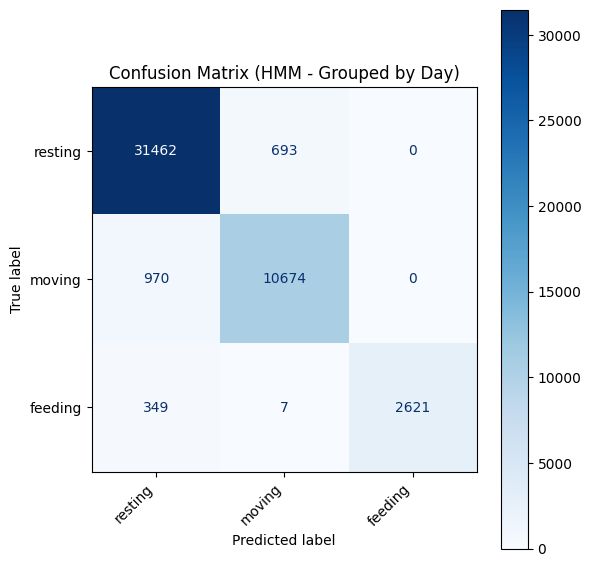

**After a discussion, we realized that while this model's metrics are the highest, there is a significant risk that we are overfitting to this particular individual because the HMM contains a time prior that severely restricts feeding predictions to days where there is empirically corroborated feeding (days 06 to 11). Therefore, this current model penalizes feeding outside of those dates and reduces likelihood of the model wrongly predicting feeding where we know it is empirically impossible to have occurred. While this is great for improving the metrics of this model, it runs the risk of overfitting and decreasing the generalizability once we try to apply the same model to other individual's data. Therefore, the next recommendation is to re-run the HMM but without the time prior (while retaining the grouped-by-day split), so that we can get a more accurate sense of how the model is doing without any input on feeding timeframes. Then we can perform the visual review from this model's output. Afterwards, we probably don't wanna spend too much time tuning the RF+HMM further for this individual. Instead, we can use what we learn from the visual review and incorporate it into our deep learning/RNN step.**

In [ ]:
# =========================================
# 123F – HMM (grouped-by-day, NO time prior) + Tuning
# Reuses the 10s RF (Wang + autocorr) pipeline
# Compares HMM with original time prior vs HMM with NO time prior (but with diag floors and gap-fill)
# =========================================

import os, re, glob, math, warnings
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
from collections import Counter

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt # Import matplotlib for confusion matrix display

warnings.filterwarnings("ignore", category=UserWarning)

# ----- Safe mount (no-op if already mounted) -----
if os.path.isdir("/content/drive/MyDrive"):
    print("Drive already mounted; skipping.")
else:
    drive.mount("/content/drive", force_remount=False)

# ----- Config -----
DATA_ROOT   = "/content/drive/MyDrive/123F Labeled Accel Data (Final)"
FS          = 16.0
WINDOW_SEC  = 10.0
OVERLAP     = 0.5
HOP_S       = WINDOW_SEC * (1.0 - OVERLAP)  # 5 s per window step
LABELS_ORDER = ["resting", "moving", "feeding"]
TARGET_LABELS = set(LABELS_ORDER)
BANDS = [(0.1,0.5),(0.5,2.0),(2.0,4.0),(4.0,6.0),(6.0,8.0)]
RNG_SEED = 42

# Baseline prior factor for feeding outside allowed times (for comparison only in this cell)
FEEDING_PRIOR_BASE = 0.01

# Transition diagonal floors (stickiness) for the 'tuned' HMM without prior
DIAG_FLOOR_ALL   = 0.80
DIAG_FLOOR_FEED  = 0.85

# Post-process: fill short non-feeding gaps inside feeding bouts (K windows)
K_GAP_FILL_FEED = 4   # 4 windows * 5 s = 20 s gaps are closed

# ----- File discovery & columns -----
AX_COL, AY_COL, AZ_COL = "Acc X [g]", "Acc Y [g]", "Acc Z [g]"
SEC_COL, LAB_COL = "Seconds", "Label"

def find_all_hour_files(data_root: str):
    patt1 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.csv"), recursive=True)
    patt2 = glob.glob(os.path.join(data_root, "**", "*_synced_labeled.CSV"), recursive=True)
    return sorted(set(patt1 + patt2))

def is_hour_15(path: str) -> bool:
    base = os.path.basename(path)
    m = re.search(r"_(\d{2})_synced_labeled\.csv$", base, flags=re.IGNORECASE)
    return (m is not None) and (m.group(1) == "15")

def normalize_label_series(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()

# ----- Feature helpers (as in your pipeline) -----
def moving_average(x: np.ndarray, k: int) -> np.ndarray:
    if k <= 1 or len(x) == 0: return x.copy()
    kern = np.ones(k, dtype=float) / float(k)
    return np.convolve(x, kern, mode="same")

def compute_dynamic(ax, ay, az, fs, win_sec=2.0):
    k = max(1, int(round(win_sec * fs)))
    ax_stat = moving_average(ax, k)
    ay_stat = moving_average(ay, k)
    az_stat = moving_average(az, k)
    dx, dy, dz = ax - ax_stat, ay - ay_stat, az - az_stat
    dm = np.sqrt(dx*dx + dy*dy + dz*dz)
    return dx, dy, dz, dm

def dominant_freq_amp(sig: np.ndarray, fs: float):
    n = len(sig)
    if n < 4: return 0.0, 0.0
    x = sig - np.nanmean(sig)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    if len(freqs) <= 1: return 0.0, 0.0
    X = X.copy(); X[0] = 0.0 + 0.0j
    idx = int(np.nanargmax(np.abs(X)))
    return float(freqs[idx]), float(np.abs(X[idx]))

def bandpowers(sig: np.ndarray, fs: float, bands):
    if len(sig) < 4: return [0.0]*len(bands)
    x = sig - np.nanmean(sig)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    X = np.fft.rfft(x)
    psd = (np.abs(X) ** 2) / max(n,1)
    out = []
    for (f1,f2) in bands:
        m = (freqs>=f1) & (freqs<f2)
        out.append(float(np.nanmean(psd[m])) if np.any(m) else 0.0)
    return out

def ac_features(sig: np.ndarray, fs: float, max_lag_s: float = 1.5):
    n = len(sig); out = {"ac_max":0.0,"ac_lag_max_s":0.0,"ac_mean_3_8":0.0,"ac_mean_9_16":0.0}
    if n < 4: return out
    x = sig - np.nanmean(sig)
    corr = np.correlate(x, x, mode="full")
    mid = len(corr)//2
    ac = corr[mid:]
    if ac[0] <= 0: return out
    ac = ac / ac[0]
    L = min(int(round(max_lag_s*fs)), len(ac)-1)
    if L < 1: return out
    ac_pos = ac[1:L+1]
    k = int(np.argmax(ac_pos))
    out["ac_max"] = float(ac_pos[k])
    out["ac_lag_max_s"] = float((k+1)/fs)
    def safe_mean(lo,hi):
        lo = max(lo,1); hi = min(hi, len(ac)-1)
        if hi < lo: return 0.0
        seg = ac[lo:hi+1]
        return float(np.nanmean(seg)) if seg.size else 0.0
    out["ac_mean_3_8"]  = safe_mean(3,8)
    out["ac_mean_9_16"] = safe_mean(9,16)
    return out

def build_feature_table(files: List[str], fs: float, window_sec: float, overlap: float):
    WINDOW = int(window_sec * fs)
    HOP = max(1, int(WINDOW * (1 - overlap)))
    rows = []
    for path in files:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print("Failed to read:", os.path.basename(path), "->", e); continue
        df[LAB_COL] = normalize_label_series(df[LAB_COL])
        df = df[df[LAB_COL].isin(TARGET_LABELS)].copy()
        if df.empty: continue

        ax = pd.to_numeric(df[AX_COL], errors="coerce").to_numpy()
        ay = pd.to_numeric(df[AY_COL], errors="coerce").to_numpy()
        az = pd.to_numeric(df[AZ_COL], errors="coerce").to_numpy()
        sec = pd.to_numeric(df[SEC_COL], errors="coerce").to_numpy()
        lab = df[LAB_COL].to_numpy()
        n = len(df)
        if n < WINDOW: continue

        dx, dy, dz, dm = compute_dynamic(ax, ay, az, fs, win_sec=2.0)
        mag = np.sqrt(ax*ax + ay*ay + az*az)

        for start in range(0, n - WINDOW + 1, HOP):
            end = start + WINDOW
            sl = slice(start, end)
            win_labels = lab[sl]
            if len(win_labels)==0: continue
            win_label = pd.Series(win_labels).value_counts().index[0]
            if win_label not in TARGET_LABELS: continue

            axw, ayw, azw = ax[sl], ay[sl], az[sl]
            dxw, dyw, dzw, dmw = dx[sl], dy[sl], dz[sl], dm[sl]
            magw = mag[sl]

            feats = {}
            # basic stats
            for nm, arr in [("ax",axw),("ay",ayw),("az",azw),("mag",magw)]:
                feats[f"{nm}_mean"] = float(np.nanmean(arr))
                feats[f"{nm}_std"]  = float(np.nanstd(arr))
                feats[f"{nm}_min"]  = float(np.nanmin(arr))
                feats[f"{nm}_max"]  = float(np.nanmax(arr))
                q75, q25 = np.nanpercentile(arr, 75), np.nanpercentile(arr, 25)
                feats[f"{nm}_iqr"]  = float(q75 - q25)
                feats[f"{nm}_madiff"] = float(np.nanmean(np.abs(np.diff(arr)))) if len(arr)>1 else 0.0

            # Wang-style dynamics
            feats["ODBA_X"] = float(np.nanmean(np.abs(dxw)))
            feats["ODBA_Y"] = float(np.nanmean(np.abs(dyw)))
            feats["ODBA_Z"] = float(np.nanmean(np.abs(dzw)))
            feats["ODBA_Sum"] = feats["ODBA_X"] + feats["ODBA_Y"] + feats["ODBA_Z"]
            feats["SDX_dyn"] = float(np.nanstd(dxw))
            feats["SDY_dyn"] = float(np.nanstd(dyw))
            feats["SDZ_dyn"] = float(np.nanstd(dzw))
            feats["SDM_dyn"] = float(np.nanstd(dmw))
            for nm, arr in [("X",dxw),("Y",dyw),("Z",dzw),("M",dmw)]:
                f_dom, amp_dom = dominant_freq_amp(arr, FS)
                feats[f"DF{nm}"] = f_dom
                feats[f"Amp{nm}"] = amp_dom

            # Bandpowers
            bp = bandpowers(dmw, FS, BANDS)
            for i,(f1,f2) in enumerate(BANDS):
                feats[f"dm_bp_{f1:.1f}_{f2:.1f}"] = bp[i]

            # Autocorr features
            feats.update(ac_features(dmw, FS, max_lag_s=1.5))

            feats["t_start"]   = float(sec[start]) if not math.isnan(sec[start]) else float(start/FS)
            feats["t_end"]     = float(sec[end-1]) if not math.isnan(sec[end-1]) else float((end-1)/FS)
            feats["hour_file"] = os.path.basename(path)
            feats["day_key"]   = feats["hour_file"].split("_")[0]  # e.g., '211206'
            feats["label"]     = win_label
            rows.append(feats)
    return pd.DataFrame(rows)

# ----- 5-window smoothing -----
def majority_with_tiebreak(seq, center_label):
    cnt = Counter(seq).most_common()
    if len(cnt)==1: return cnt[0][0]
    if cnt[0][1] > cnt[1][1]: return cnt[0][0]
    return center_label

def smooth_group_k(g, k=5):
    vals = g["pred_raw"].to_list()
    smoothed = []
    n = len(vals); half = k//2
    for i in range(n):
        idxs = [j for j in range(i-half, i+half+1) if 0 <= j < n]
        win = [vals[j] for j in idxs]
        smoothed.append(majority_with_tiebreak(win, vals[i]))
    g["pred_5w"] = smoothed
    return g

# ----- HMM helpers -----
STATE2IDX = {s:i for i,s in enumerate(LABELS_ORDER)}

def estimate_transitions(train_df: pd.DataFrame, labels_order: List[str], laplace: float = 1e-3):
    K = len(labels_order)
    counts = np.ones((K, K), dtype=float) * laplace
    for _, g in train_df.sort_values(["hour_file","t_start"]).groupby("hour_file"):
        labs = g["label"].tolist()
        for a, b in zip(labs, labs[1:]):
            if a in STATE2IDX and b in STATE2IDX:
                counts[STATE2IDX[a], STATE2IDX[b]] += 1.0
    trans = counts / counts.sum(axis=1, keepdims=True)
    init_counts = np.ones(K, dtype=float) * laplace
    for _, g in train_df.sort_values(["hour_file","t_start"]).groupby("hour_file"):
        if len(g): init_counts[STATE2IDX[g["label"].iloc[0]]] += 1.0
    init = init_counts / init_counts.sum()
    return trans, init

def apply_diag_floor(trans: np.ndarray, floor_all: float, floor_feed: float) -> np.ndarray:
    T = trans.copy()
    K = T.shape[0]
    for i in range(K):
        floor = floor_feed if i == STATE2IDX["feeding"] else floor_all
        if T[i, i] < floor:
            off = T[i, :].copy(); off[i] = 0.0
            off_sum = off.sum()
            T[i, i] = floor
            if off_sum > 0:
                T[i, :] = T[i, :] * (1.0 - floor) / off_sum
                T[i, i] = floor
            else:
                # if degenerate, distribute tiny mass uniformly
                T[i, :] = (1.0 - floor) / (K-1)
                T[i, i] = floor
        # renormalize (safety)
        row_sum = T[i, :].sum()
        if row_sum > 0: T[i, :] /= row_sum
    return T

def log_safe(x, eps=1e-12):
    return np.log(np.clip(x, eps, 1.0))

def feeding_allowed(day_key: str, hour_file: str) -> bool:
    """Allow feeding only days 06–11; on day 06 only from hour >=22."""
    try:
        dom = int(re.sub(r"\D", "", day_key)[-2:])  # day-of-month
    except:
        return True
    m = re.search(r"_(\d{2})_", "_" + hour_file + "_")
    hour = int(m.group(1)) if m else 0
    if 7 <= dom <= 11: return True
    if dom == 6 and hour >= 22: return True
    return False

def time_prior_logvec(day_key: str, hour_file: str, n_steps: int, factor: float):
    """Additive log prior per timestep; multiply feeding by 'factor' when disallowed."""
    K = len(LABELS_ORDER)
    out = np.zeros((n_steps, K), dtype=float)
    if not feeding_allowed(day_key, hour_file):
        out[:, STATE2IDX["feeding"]] = np.log(factor)  # factor < 1 downweights feeding
    return out


def viterbi_decode_log(emissions_log: np.ndarray, log_init: np.ndarray, log_trans: np.ndarray, add_log_prior: np.ndarray):
    T, K = emissions_log.shape
    dp = np.full((T, K), -1e18, dtype=float)
    back = np.full((T, K), -1, dtype=int)
    dp[0] = log_init + emissions_log[0] + add_log_prior[0]
    for t in range(1, T):
        prev = dp[t-1][:, None] + log_trans  # (K,1)+(K,K)->(K,K)
        back[t] = np.argmax(prev, axis=0)
        dp[t] = prev[back[t], range(K)] + emissions_log[t] + add_log_prior[t]
    path = np.zeros(T, dtype=int)
    path[-1] = int(np.argmax(dp[-1]))
    for t in range(T-2, -1, -1):
        path[t] = back[t+1, path[t+1]]
    return path

# Post-process: fill short non-feeding gaps inside feeding
def fill_short_nonfeed_gaps(labels: list, target="feeding", k_gap=4):
    if len(labels) == 0: return labels
    runs = []
    cur = labels[0]; L = 1
    for x in labels[1:]:
        if x == cur: L += 1
        else: runs.append([cur, L]); cur = x; L = 1
    runs.append([cur, L])
    # Walk runs; if a non-target run is shorter than k_gap and it's surrounded by target runs, flip it
    out_runs = runs[:]
    for i in range(1, len(out_runs)-1):
        lab, length = out_runs[i]
        if lab != target and length < k_gap:
            if out_runs[i-1][0] == target and out_runs[i+1][0] == target:
                out_runs[i][0] = target
    # Reconstruct sequence
    out = []
    for lab, length in out_runs:
        out.extend([lab]*length)
    return out

# ----- Metrics & utilities -----
def metrics_table(y_true, y_pred, label="model"):
    rep = classification_report(y_true, y_pred, labels=LABELS_ORDER, target_names=LABELS_ORDER, zero_division=0, output_dict=True)
    acc = accuracy_score(y_true, y_pred)
    return {
        "which": label,
        "acc": round(acc, 4),
        "macroF1": round(rep["macro avg"]["f1-score"], 4),
        "restF1": round(rep["resting"]["f1-score"], 4),
        "moveF1": round(rep["moving"]["f1-score"], 4),
        "feedP": round(rep["feeding"]["precision"], 4),
        "feedR": round(rep["feeding"]["recall"], 4),
        "feedF1": round(rep["feeding"]["f1-score"], 4),
    }

def budget_seconds(labels):
    s = pd.Series(labels, name="lbl"); counts = s.value_counts()
    return {lab: counts.get(lab, 0) * HOP_S for lab in LABELS_ORDER}

def bias_minutes(pred_se, true_se):
    return {k: (pred_se[k]-true_se[k])/60.0 for k in LABELS_ORDER}

# ----- Build or reuse features -----
FILES_ALL = find_all_hour_files(DATA_ROOT)
FILES = [f for f in FILES_ALL if not is_hour_15(f)]
print(f"Found {len(FILES_ALL)} files; using {len(FILES)} (excluded hour-15).")

try:
    data  # reuse if exists
    assert isinstance(data, pd.DataFrame) and len(data)>0
    print("Reusing existing feature table:", data.shape)
except:
    print("Building features…")
    data = build_feature_table(FILES, FS, WINDOW_SEC, OVERLAP)
    print("Feature table:", data.shape)
    print("Label counts:\n", data["label"].value_counts())

# ----- Grouped-by-day split (ensure feeding in test) -----
def grouped_split_by_day(df: pd.DataFrame, test_frac=0.2, seed=RNG_SEED):
    rng = np.random.RandomState(seed)
    days = df["day_key"].unique().tolist()
    feed_days = set(df[df["label"]=="feeding"]["day_key"].unique().tolist())
    target_n = max(1, int(round(len(days)*test_frac)))
    # ensure at least one feeding day in test
    test_days = set([rng.choice(list(feed_days))]) if len(feed_days)>0 else set()
    remaining = [d for d in days if d not in test_days]
    rng.shuffle(remaining)
    for d in remaining:
        if len(test_days) >= target_n: break
        test_days.add(d)
    mask = df["day_key"].isin(test_days)
    return df[~mask].copy(), df[mask].copy()

train_df, test_df = grouped_split_by_day(data, test_frac=0.2, seed=RNG_SEED)
if "feeding" not in test_df["label"].unique():
    print("⚠️ No feeding in test; please re-run with a different RNG_SEED.")

# ----- RF fit -----
feat_cols = [c for c in data.columns if c not in ("label","hour_file","t_start","t_end","day_key")]
X_train = train_df[feat_cols].to_numpy(); y_train = train_df["label"].to_numpy()
X_test  = test_df[feat_cols].to_numpy();  y_test  = test_df["label"].to_numpy()

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train); X_test_sc = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=500, class_weight="balanced",
    n_jobs=-1, random_state=RNG_SEED, bootstrap=True, max_features="sqrt"
)
rf.fit(X_train_sc, y_train)

# Raw predictions + probs
y_pred_raw = rf.predict(X_test_sc)
proba = rf.predict_proba(X_test_sc)
classes = list(rf.classes_); class_index = {c:i for i,c in enumerate(classes)}
P = np.zeros((len(y_test), len(LABELS_ORDER)), dtype=float)
for i, lab in enumerate(LABELS_ORDER):
    if lab in class_index: P[:, i] = proba[:, class_index[lab]]

# 5-window smoothing per hour_file
pred_df = test_df[["hour_file","day_key","t_start","label"]].copy().rename(columns={"label":"true_label"})
pred_df["pred_raw"] = y_pred_raw
pred_df = pred_df.sort_values(["hour_file","t_start"]).reset_index(drop=True)
pred_df = pred_df.groupby("hour_file", group_keys=False).apply(lambda g: smooth_group_k(g, k=5))

# Align back to original order
keyed = pred_df.set_index(["hour_file","t_start"])
pred_5w = [keyed.loc[(r["hour_file"], r["t_start"]), "pred_5w"] for _, r in test_df[["hour_file","t_start"]].iterrows()]
y_pred_5w = np.array(pred_5w, dtype=object)

# ----- HMM baseline (prior 0.01, raw transitions) -----
trans_base, init_base = estimate_transitions(train_df, LABELS_ORDER, laplace=1e-3)
log_trans_base = log_safe(trans_base); log_init_base = log_safe(init_base)

hmm_base = np.empty(len(test_df), dtype=object)
test_sorted = test_df.sort_values(["hour_file","t_start"]).reset_index()
for hour, g in test_sorted.groupby("hour_file"):
    idxs = g.index.to_numpy(); T = len(idxs)
    E = P[idxs, :]; E_log = log_safe(E)
    # Use time prior for baseline HMM
    add_prior = np.zeros((T, len(LABELS_ORDER)), dtype=float) # Initialize add_prior
    # Keep original time prior logic for baseline
    if not feeding_allowed(g["day_key"].iloc[0], hour):
         add_prior[:, STATE2IDX["feeding"]] = np.log(FEEDING_PRIOR_BASE)

    path = viterbi_decode_log(E_log, log_init_base, log_trans_base, add_prior)
    hmm_base[idxs] = np.array([LABELS_ORDER[z] for z in path], dtype=object)
# align to original row order
y_pred_hmm_base = pd.Series(hmm_base, index=test_sorted["index"]).sort_index().to_numpy()


# ----- HMM tuned (NO time prior, with diagonal floors, gap-fill) -----
trans_tuned, init_tuned = estimate_transitions(train_df, LABELS_ORDER, laplace=1e-3)
trans_tuned = apply_diag_floor(trans_tuned, DIAG_FLOOR_ALL, DIAG_FLOOR_FEED)
log_trans_tuned = log_safe(trans_tuned); log_init_tuned = log_safe(init_tuned)

hmm_tuned = np.empty(len(test_df), dtype=object)
for hour, g in test_sorted.groupby("hour_file"):
    idxs = g.index.to_numpy(); T = len(idxs)
    E = P[idxs, :]; E_log = log_safe(E)
    # REMOVE TIME PRIOR: Set add_prior to zeros
    add_prior = np.zeros((T, len(LABELS_ORDER)), dtype=float) # Removed time prior
    path = viterbi_decode_log(E_log, log_init_tuned, log_trans_tuned, add_prior)
    # post-process: fill short non-feeding gaps inside feeding bouts
    labels_seq = [LABELS_ORDER[z] for z in path]
    labels_seq = fill_short_nonfeed_gaps(labels_seq, target="feeding", k_gap=K_GAP_FILL_FEED)
    hmm_tuned[idxs] = np.array(labels_seq, dtype=object)
y_pred_hmm_tuned = pd.Series(hmm_tuned, index=test_sorted["index"]).sort_index().to_numpy()

# ----- Metrics -----
true_secs   = budget_seconds(y_test)
raw_secs    = budget_seconds(y_pred_raw)
w5_secs     = budget_seconds(y_pred_5w)
hmm_b_secs  = budget_seconds(y_pred_hmm_base)
hmm_t_secs  = budget_seconds(y_pred_hmm_tuned)

m_raw  = metrics_table(y_test, y_pred_raw,        label="group_by_day:raw")
m_5w   = metrics_table(y_test, y_pred_5w,         label="group_by_day:5w")
m_hb   = metrics_table(y_test, y_pred_hmm_base,   label="group_by_day:hmm_base_prior") # Renamed for clarity
m_ht   = metrics_table(y_test, y_pred_hmm_tuned,  label="group_by_day:hmm_noprior") # Renamed for clarity

comp = pd.DataFrame([m_raw, m_5w, m_hb, m_ht])
print("\n=== Grouped-by-day: raw vs 5w vs HMM_base(prior) vs HMM_tuned(noprior) ===")
display(comp) # Use display for better formatting

def fmt_bias(d): return {k: f"{v:+.1f} min" for k,v in d.items()}
print("\nBudget bias (Pred − True):")
print("  raw       :", fmt_bias(bias_minutes(raw_secs,   true_secs)))
print("  5w        :", fmt_bias(bias_minutes(w5_secs,    true_secs)))
print("  hmm_base_prior  :", fmt_bias(bias_minutes(hmm_b_secs, true_secs)))
print("  hmm_tuned_noprior :", fmt_bias(bias_minutes(hmm_t_secs, true_secs)))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd # Import pandas for better table display

labels = LABELS_ORDER  # ["resting","moving","feeding"]
y_true = y_test
# Assuming y_pred_hmm_tuned is available from the previous cell execution

# Generate and display the confusion matrix
cm = confusion_matrix(y_true, y_pred_hmm_tuned, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix (HMM - Grouped by Day, No Time Prior)") # Updated title
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Generate and display the classification report as a table
report = classification_report(y_true, y_pred_hmm_tuned, labels=labels, target_names=labels, zero_division=0, output_dict=True)

# Convert the report dictionary to a pandas DataFrame for better display
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report (HMM - Grouped by Day, No Time Prior):") # Updated title
display(report_df)

**Now we can generate a CSV file for the mismatches generated by this latest "HMM w/o time prior model" for us to review on Raven**

In [ ]:
# =========================================
# 123F — HMM-only review CSV (compact) - NO time prior
# Purpose: generate a small, focused CSV for manual checks in Raven
# Requires in memory: test_df, y_test, y_pred_hmm_tuned, P, LABELS_ORDER
# =========================================

import os
import numpy as np
import pandas as pd
from datetime import datetime

# -----------------------------
# Sanity checks (alignment & config)
# -----------------------------
needed = ["test_df", "y_test", "y_pred_hmm_tuned", "P", "LABELS_ORDER"]
missing = [v for v in needed if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables: {missing}. "
        "Please ensure the latest HMM cell (grouped-by-day, NO time prior) ran successfully."
    )

assert isinstance(test_df, pd.DataFrame) and len(test_df) > 0, "test_df is empty or not a DataFrame"
assert len(y_test) == len(test_df), "y_test length does not match test_df"
assert len(y_pred_hmm_tuned) == len(test_df), "y_pred_hmm_tuned length does not match test_df"
assert P.shape[0] == len(test_df), "P rows do not align with test_df rows"
assert list(LABELS_ORDER) == ["resting", "moving", "feeding"], "Unexpected LABELS_ORDER ordering"

# -----------------------------
# Build HMM-only review table
# -----------------------------
review = test_df[["hour_file", "day_key", "t_start", "t_end"]].copy()
review["true_label"] = np.array(y_test, dtype=object)
review["pred_hmm"]   = np.array(y_pred_hmm_tuned, dtype=object)

# Probabilities aligned to LABELS_ORDER = ['resting','moving','feeding']
idx_rest = LABELS_ORDER.index("resting")
idx_move = LABELS_ORDER.index("moving")
idx_feed = LABELS_ORDER.index("feeding")

review["p_resting"] = P[:, idx_rest]
review["p_moving"]  = P[:, idx_move]
review["p_feeding"] = P[:, idx_feed]
review["p_max"]     = P.max(axis=1)

# Confidence margin: (best prob - second best prob)
P_sorted = np.sort(P, axis=1)
review["p_margin"] = P_sorted[:, -1] - P_sorted[:, -2]

# Disagreement flag
review["disagree_hmm"] = (review["pred_hmm"] != review["true_label"])

# -----------------------------
# Feeding entry/exit edges within each hour
# -----------------------------
def mark_edges(df: pd.DataFrame, col: str) -> pd.DataFrame:
    df = df.sort_values(["hour_file", "t_start"]).copy()
    prev = df.groupby("hour_file", sort=False)[col].shift(1)
    edge = (df[col] != prev) & prev.notna()
    df[f"{col}_edge"] = edge
    df[f"{col}_edge_feeding"] = edge & ((df[col] == "feeding") | (prev == "feeding"))
    return df

review = mark_edges(review, "true_label")
review = mark_edges(review, "pred_hmm")

# -----------------------------
# Filter to compact, high-signal sample
# -----------------------------
LOWCONF = 0.60  # low-confidence threshold
interesting = (
    review["disagree_hmm"] |
    review["pred_hmm_edge_feeding"] |
    review["true_label_edge_feeding"] |
    (review["p_max"] < LOWCONF)
)

sample = review[interesting].copy()

# Reason tags: why each row was selected
def combine_reasons(row) -> str:
    reasons = []
    if row["disagree_hmm"]: reasons.append("disagree")
    if row["pred_hmm_edge_feeding"]: reasons.append("pred_feed_edge")
    if row["true_label_edge_feeding"]: reasons.append("true_feed_edge")
    if row["p_max"] < LOWCONF: reasons.append("low_conf")
    return "|".join(reasons) if reasons else "—"

sample["reason"] = sample.apply(combine_reasons, axis=1)

# Priority: disagreement > pred feeding edge > true feeding edge > low confidence
sample["prio"] = (
    sample["disagree_hmm"].astype(int) * 4 +
    sample["pred_hmm_edge_feeding"].astype(int) * 3 +
    sample["true_label_edge_feeding"].astype(int) * 2 +
    (sample["p_max"] < LOWCONF).astype(int) * 1
)

# Sort by hour, time, and priority (desc)
sample = sample.sort_values(["hour_file", "t_start", "prio"], ascending=[True, True, False])


# -----------------------------
# Cap to a small file WITHOUT early-in-hour bias
# (time-stratified picks per hour_file)
# -----------------------------
MAX_ROWS = 1000  # adjust as needed

if len(sample) > MAX_ROWS:
    n_hours = max(1, sample["hour_file"].nunique())
    per_hour = max(1, int(MAX_ROWS / n_hours))

    picks = []
    for _, g in sample.groupby("hour_file", sort=False):
        if len(g) <= per_hour:
            picks.append(g)
        else:
            # time-stratified selection across the hour
            idx = np.linspace(0, len(g) - 1, num=per_hour, dtype=int)
            picks.append(g.iloc[idx])
    sample = pd.concat(picks).sort_values(["hour_file", "t_start"])

    # If still slightly over due to rounding, trim tail
    if len(sample) > MAX_ROWS:
        sample = sample.head(MAX_ROWS)

# Tidy up
sample = sample.drop(columns=["prio"]).reset_index(drop=True)
sample["model"] = "hmm_noprior"  # self-describing provenance

# -----------------------------
# Write files
# -----------------------------
STAMP = datetime.now().strftime("%Y%m%d_%H%M")
OUT_DIR = "/content/drive/MyDrive/123F Models/review_exports"
os.makedirs(OUT_DIR, exist_ok=True)

sample_path = os.path.join(OUT_DIR, f"{STAMP}_review_hmm_noprior_sample.csv")
sample.to_csv(sample_path, index=False)
print(f"Saved HMM (NO PRIOR) REVIEW SAMPLE ({len(sample)} rows): {sample_path}")

# Optional: full table
WRITE_FULL = False
if WRITE_FULL:
    full_path = os.path.join(OUT_DIR, f"{STAMP}_review_hmm_noprior_full.csv")
    review.to_csv(full_path, index=False)
    print(f"Saved FULL HMM (NO PRIOR) CSV ({len(review)} rows): {full_path}")

# -----------------------------
# Tips for manual verification
# -----------------------------
print("\nHow to use:")
print("- Open the hour files in 'hour_file' and jump to [t_start, t_end] in Raven.")
print("- Prioritize rows with 'disagree' in 'reason', then 'pred_feed_edge'/'true_feed_edge', then 'low_conf'.")
print("- Use 'p_feeding', 'p_max', and 'p_margin' to gauge confidence; low 'p_margin' means ambiguous.")

**The previous code is good for reviewing where the model is uncertain, i.e. the csv prioritizes subtle/ambiguous cases where human inspection may be useful to spot why it's getting certain guesses wrong. However, it does NOT show us the "wrong but confident" side of the model (remember that feeding precision in this latest HMM model is 0.79). For that, we can structure a new csv that can show us high-confidence errors.**

In [ ]:
# =========================================
# Confident Mistakes CSV (HMM, NO time prior)
# Flags errors where the model was confident in its (wrong) prediction
# Requires: test_df, y_test, y_pred_hmm_tuned, P, LABELS_ORDER
# =========================================

import os, numpy as np, pandas as pd
from datetime import datetime

# --- Sanity checks ---
need = ["test_df","y_test","y_pred_hmm_tuned","P","LABELS_ORDER"]
missing = [v for v in need if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables: {missing}. Run the HMM cell first: {missing}")

assert list(LABELS_ORDER) == ["resting","moving","feeding"], f"Unexpected LABELS_ORDER: {LABELS_ORDER}"
assert len(test_df)==len(y_test)==len(y_pred_hmm_tuned)==P.shape[0], "Shape mismatch among inputs"

# --- Helper indices ---
state2idx = {s:i for i,s in enumerate(LABELS_ORDER)}
pred_idx = np.array([state2idx[l] for l in y_pred_hmm_tuned])
true_idx = np.array([state2idx[l] for l in y_test])

# RF confidences (note: these are RF probs, not HMM posteriors)
p_pred = P[np.arange(P.shape[0]), pred_idx]  # prob of the class that HMM ultimately chose
p_true = P[np.arange(P.shape[0]), true_idx]  # prob of the true class
p_max  = P.max(axis=1)
argmax_idx = P.argmax(axis=1)
argmax_label = np.array([LABELS_ORDER[i] for i in argmax_idx])

# --- Define "confident error"
THR = 0.80  # confidence threshold; raise to 0.85/0.90 for stricter set
# Confident if either:
#  (A) RF's top class equals HMM's predicted class AND p_max >= THR
#  OR
#  (B) RF assigns >= THR probability to the HMM-predicted class (even if it's not the argmax)
confident_mask = ((argmax_idx == pred_idx) & (p_max >= THR)) | (p_pred >= THR)

error_mask = (y_pred_hmm_tuned != y_test)
confident_error_mask = error_mask & confident_mask

# --- Build the table
conf_err = test_df.loc[confident_error_mask, ["hour_file","day_key","t_start","t_end"]].copy()
conf_err["true_label"] = np.array(y_test)[confident_error_mask]
conf_err["pred_hmm"]   = np.array(y_pred_hmm_tuned)[confident_error_mask]
conf_err["p_pred"]     = p_pred[confident_error_mask]
conf_err["p_true"]     = p_true[confident_error_mask]
conf_err["p_max"]      = p_max[confident_error_mask]
conf_err["rf_top_label"] = argmax_label[confident_error_mask]
# margin between top and second-best RF probs
P_sorted = np.sort(P[confident_error_mask, :], axis=1)
conf_err["p_margin"] = P_sorted[:, -1] - P_sorted[:, -2]
conf_err["reason"]   = "confident_error"
conf_err["model"]    = "hmm_noprior"

# --- Optional: focus on where HMM predicted feeding (precision pain point)
# conf_err = conf_err[conf_err["pred_hmm"] == "feeding"].copy()

# --- Optional: cap size (stratified by day to keep it reviewable)
MAX_ROWS = 400  # adjust or set to None to keep all
if MAX_ROWS and len(conf_err) > MAX_ROWS:
    picks = []
    n_days = max(1, conf_err["day_key"].nunique())
    per_day = max(1, int(MAX_ROWS / n_days))
    for _, g in conf_err.sort_values(["day_key","hour_file","t_start"]).groupby("day_key", sort=False):
        if len(g) <= per_day:
            picks.append(g)
        else:
            idx = np.linspace(0, len(g)-1, num=per_day, dtype=int)  # time-stratified per day
            picks.append(g.iloc[idx])
    conf_err = pd.concat(picks).sort_values(["day_key","hour_file","t_start"])

# --- Save
STAMP = datetime.now().strftime("%Y%m%d_%H%M")
OUT_DIR = "/content/drive/MyDrive/123F Models/review_exports"
os.makedirs(OUT_DIR, exist_ok=True)
out_path = os.path.join(OUT_DIR, f"{STAMP}_confident_errors_hmm_noprior_thr{int(THR*100)}.csv")
conf_err.to_csv(out_path, index=False)

print(f"Saved Confident Mistakes CSV: {out_path}")
print("Counts by predicted class:")
print(conf_err["pred_hmm"].value_counts())
